In [1]:
# Import Main Data Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
# Group by group and sum only certain values
# Example df to show how to group by zip code and sum only x values
import pandas as pd

# Sample DataFrame
data = {
    'Zip Code': ['A', 'A', 'B', 'B', 'A'],
    'Fuel': ['x', 'y', 'x', 'y', 'x'],
    'Vehicles': [10, 20, 30, 40, 50]
}

df = pd.DataFrame(data)

# Filter the DataFrame to include only rows where 'category' is 'x'
filtered_df = df[df['Fuel'] == 'x']

# Grouping and summing
grouped_df = filtered_df.groupby('Zip Code')['Vehicles'].sum().reset_index()

print(grouped_df)

  Zip Code  Vehicles
0        A        60
1        B        30


# 07 - Redo chargers + population chart

## 07.1 - Remake stacked bar chart of city + zip

In [3]:
# Import new charger data
charger_link_new = 'https://raw.githubusercontent.com/veronicaj8345/DataJam/main/Electric_Vehicle_Charging_Stations_20240403.csv'
chargers_new = pd.read_csv(charger_link_new)
chargers_new.head()

,Station Name,Station information,Phone number,Access,Access times,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,Network,Network website,Open date,Connections,Address,City,State,Zip code,Location 1
0,Nissan of Burlingame,NaN,650-347-4800,Public - Call ahead,NaN,NaN,1.0,NaN,NaN,NaN,01/31/2012,J1772,101 California Dr,Burlingame,CA,94010,NaN
1,BURLINGAME,LOT V 1; City parking lot V,888-758-4389,Public,24 hours daily,NaN,2.0,NaN,ChargePoint Network,http://www.chargepoint.com/,NaN,NaN,294-298 California Dr,Burlingame,CA,94010,"(37.5800222, -122.3452787)"
2,ALMAZ CAPITAL,WELCOME TO ALL; 2 stalls to the West from priv...,888-758-4389,Public,24 hours daily,NaN,2.0,NaN,ChargePoint Network,http://www.chargepoint.com/,NaN,NaN,3274 Alpine Rd,Portola Valley,CA,94028,"(37.3982219, -122.1926035)"
3,Grail Biotech,NaN,NaN,Private,NaN,NaN,2.0,NaN,NaN,NaN,11/15/2017,J1772,1525 O'Brien Dr,Menlo Park,CA,94025,NaN
4,GE WattStation,NaN,855-443-3873,Private,NaN,NaN,1.0,NaN,GE WattStation,https://www.gewattstation.com,NaN,NaN,1553 El Camino Real,Redwood City,CA,94063,"(37.4808266, -122.2274333)"


In [4]:
# Change NaN to 0
chargers_new[['Level 1 charging stations',
             'Level 2 charging stations',
             'DC Fast charging stations']] = chargers_new[['Level 1 charging stations',
                                                           'Level 2 charging stations',
                                                           'DC Fast charging stations']].fillna(0)
chargers_new.head()

,Station Name,Station information,Phone number,Access,Access times,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,Network,Network website,Open date,Connections,Address,City,State,Zip code,Location 1
0,Nissan of Burlingame,NaN,650-347-4800,Public - Call ahead,NaN,0.0,1.0,0.0,NaN,NaN,01/31/2012,J1772,101 California Dr,Burlingame,CA,94010,NaN
1,BURLINGAME,LOT V 1; City parking lot V,888-758-4389,Public,24 hours daily,0.0,2.0,0.0,ChargePoint Network,http://www.chargepoint.com/,NaN,NaN,294-298 California Dr,Burlingame,CA,94010,"(37.5800222, -122.3452787)"
2,ALMAZ CAPITAL,WELCOME TO ALL; 2 stalls to the West from priv...,888-758-4389,Public,24 hours daily,0.0,2.0,0.0,ChargePoint Network,http://www.chargepoint.com/,NaN,NaN,3274 Alpine Rd,Portola Valley,CA,94028,"(37.3982219, -122.1926035)"
3,Grail Biotech,NaN,NaN,Private,NaN,0.0,2.0,0.0,NaN,NaN,11/15/2017,J1772,1525 O'Brien Dr,Menlo Park,CA,94025,NaN
4,GE WattStation,NaN,855-443-3873,Private,NaN,0.0,1.0,0.0,GE WattStation,https://www.gewattstation.com,NaN,NaN,1553 El Camino Real,Redwood City,CA,94063,"(37.4808266, -122.2274333)"


In [5]:
chargers_new_1 = chargers_new[['City',
                               'Zip code',
                       'Level 1 charging stations',
                       'Level 2 charging stations',
                       'DC Fast charging stations']].copy()
chargers_new_1.head()

,City,Zip code,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations
0,Burlingame,94010,0.0,1.0,0.0
1,Burlingame,94010,0.0,2.0,0.0
2,Portola Valley,94028,0.0,2.0,0.0
3,Menlo Park,94025,0.0,2.0,0.0
4,Redwood City,94063,0.0,1.0,0.0


In [6]:
chargers_new_2 = chargers_new_1.groupby(['City', 'Zip code']).sum().reset_index()
chargers_new_2.head(10)

,City,Zip code,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations
0,Atherton,94027,28.0,28.0,0.0
1,Belmont,94002,0.0,78.0,0.0
2,Brisbane,94005,0.0,26.0,20.0
3,Burlingame,94010,0.0,157.0,19.0
4,Colma,94014,0.0,26.0,67.0
5,Daly City,94014,0.0,91.0,50.0
6,Daly City,94015,0.0,39.0,581.0
7,E. Palo Alto,94303,0.0,42.0,0.0
8,East Palo Alto,94303,0.0,33.0,260.0
9,Foster City,94404,0.0,427.0,0.0


In [7]:
chargers_new_2['Zip code'] = chargers_new_2["Zip code"].astype('object')

In [8]:
chargers_new_2

,City,Zip code,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations
0,Atherton,94027,28.0,28.0,0.0
1,Belmont,94002,0.0,78.0,0.0
2,Brisbane,94005,0.0,26.0,20.0
3,Burlingame,94010,0.0,157.0,19.0
4,Colma,94014,0.0,26.0,67.0
5,Daly City,94014,0.0,91.0,50.0
6,Daly City,94015,0.0,39.0,581.0
7,E. Palo Alto,94303,0.0,42.0,0.0
8,East Palo Alto,94303,0.0,33.0,260.0
9,Foster City,94404,0.0,427.0,0.0


<Axes: >

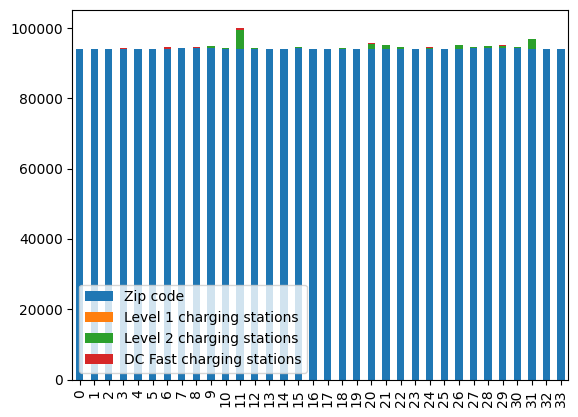

In [9]:
chargers_new_2.plot(kind='bar',stacked=True)

## 07.2 - Add population data

I pulled some new population data from [here](https://worldpopulationreview.com/us-counties/ca/san-mateo-county/zips). Add a github link later

In [10]:
# Data
data = {
    'Zip code': ['94080', '94015', '94014', '94403', '94010', '94066', '94025', '94044', '94061', '94404',
                 '94401', '94063', '94070', '94002', '94062', '94402', '94030', '94019', '94065', '94027',
                 '94028', '94005', '94018', '94038', '94037', '94020', '94060', '94074', '94021', '94128'],
    'Population': [66262, 65125, 46331, 43858, 43458, 43369, 41017, 38061, 37539, 36397,
                   35392, 34807, 31312, 27893, 26531, 26150, 22825, 15275, 11588, 7142,
                   6888, 4756, 3423, 3165, 2649, 2030, 1312, 151, 123, 0],
    'City': ['South San Francisco', 'Daly City', 'Daly City', 'San Mateo', 'Burlingame',
             'San Bruno', 'Menlo Park', 'Pacifica', 'Redwood City', 'San Mateo',
             'San Mateo', 'Redwood City', 'San Carlos', 'Belmont', 'Redwood City',
             'San Mateo', 'Millbrae', 'Half Moon Bay', 'Redwood City', 'Atherton',
             'Portola Valley', 'Brisbane', 'El Granada', 'Moss Beach', 'Montara',
             'La Honda', 'Pescadero', 'San Gregorio', 'Loma Mar', 'San Francisco']
}

# Creating DataFrame
SMC_population = pd.DataFrame(data)

SMC_population



,Zip code,Population,City
0,94080,66262,South San Francisco
1,94015,65125,Daly City
2,94014,46331,Daly City
3,94403,43858,San Mateo
4,94010,43458,Burlingame
5,94066,43369,San Bruno
6,94025,41017,Menlo Park
7,94044,38061,Pacifica
8,94061,37539,Redwood City
9,94404,36397,San Mateo


In [11]:
SMC_population.dtypes

Zip code      object
Population     int64
City          object
dtype: object

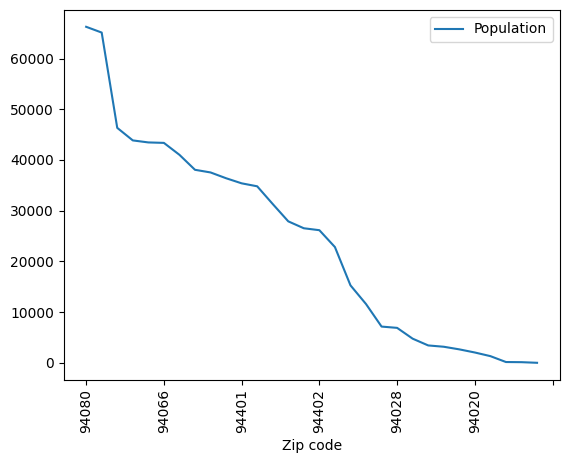

In [12]:
# Test line plot
SMC_population.plot(kind='line', x='Zip code', y= 'Population')
plt.xticks(rotation=90)
plt.show()

## 07.3 - Stick them together

In [13]:
chargers_new_2.dtypes

City                          object
Zip code                      object
Level 1 charging stations    float64
Level 2 charging stations    float64
DC Fast charging stations    float64
dtype: object

In [14]:
# Join dfs

chargers_pop = pd.merge(SMC_population, chargers_new_2, on='Zip code', how='outer')
chargers_pop

,Zip code,Population,City_x,City_y,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations
0,94002,NaN,NaN,Belmont,0.0,78.0,0.0
1,94005,NaN,NaN,Brisbane,0.0,26.0,20.0
2,94010,NaN,NaN,Burlingame,0.0,157.0,19.0
3,94014,NaN,NaN,Colma,0.0,26.0,67.0
4,94014,NaN,NaN,Daly City,0.0,91.0,50.0
...,...,...,...,...,...,...,...
59,94128,0.0,San Francisco,NaN,NaN,NaN,NaN
60,94401,35392.0,San Mateo,NaN,NaN,NaN,NaN
61,94402,26150.0,San Mateo,NaN,NaN,NaN,NaN
62,94403,43858.0,San Mateo,NaN,NaN,NaN,NaN


In [15]:
# Normalize zip code values
chargers_new_2['Zip code'] = chargers_new_2['Zip code'].astype(str).str.strip()
SMC_population['Zip code'] = SMC_population['Zip code'].astype(str).str.strip()

# Perform the merge again
merged_df = pd.merge(chargers_new_2, SMC_population, on='Zip code', how='outer')

# Display the merged dataframe
merged_df


,City_x,Zip code,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,Population,City_y
0,Belmont,94002,0.0,78.0,0.0,27893.0,Belmont
1,Brisbane,94005,0.0,26.0,20.0,4756.0,Brisbane
2,Burlingame,94010,0.0,157.0,19.0,43458.0,Burlingame
3,Colma,94014,0.0,26.0,67.0,46331.0,Daly City
4,Daly City,94014,0.0,91.0,50.0,46331.0,Daly City
5,Daly City,94015,0.0,39.0,581.0,65125.0,Daly City
6,NaN,94018,NaN,NaN,NaN,3423.0,El Granada
7,Half Moon Bay,94019,0.0,211.0,50.0,15275.0,Half Moon Bay
8,NaN,94020,NaN,NaN,NaN,2030.0,La Honda
9,NaN,94021,NaN,NaN,NaN,123.0,Loma Mar


# 06 - New charger data

I'm not sure exactly why but there is 2 different versions of the charger data on the SMC datahub site. [This version](https://datahub.smcgov.org/Transportation/Electric-Vehicle-Charging-Stations/jt88-t8fu) seems to be more complete compared to the [original dataset.](https://datahub.smcgov.org/Transportation/San-Mateo-Electric-Vehicle-Charging-Stations/62me-9htk)  

In [16]:
# Import new charger data
charger_link_new = 'https://raw.githubusercontent.com/veronicaj8345/DataJam/main/Electric_Vehicle_Charging_Stations_20240403.csv'
chargers_new = pd.read_csv(charger_link_new)
chargers_new.head()

,Station Name,Station information,Phone number,Access,Access times,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,Network,Network website,Open date,Connections,Address,City,State,Zip code,Location 1
0,Nissan of Burlingame,NaN,650-347-4800,Public - Call ahead,NaN,NaN,1.0,NaN,NaN,NaN,01/31/2012,J1772,101 California Dr,Burlingame,CA,94010,NaN
1,BURLINGAME,LOT V 1; City parking lot V,888-758-4389,Public,24 hours daily,NaN,2.0,NaN,ChargePoint Network,http://www.chargepoint.com/,NaN,NaN,294-298 California Dr,Burlingame,CA,94010,"(37.5800222, -122.3452787)"
2,ALMAZ CAPITAL,WELCOME TO ALL; 2 stalls to the West from priv...,888-758-4389,Public,24 hours daily,NaN,2.0,NaN,ChargePoint Network,http://www.chargepoint.com/,NaN,NaN,3274 Alpine Rd,Portola Valley,CA,94028,"(37.3982219, -122.1926035)"
3,Grail Biotech,NaN,NaN,Private,NaN,NaN,2.0,NaN,NaN,NaN,11/15/2017,J1772,1525 O'Brien Dr,Menlo Park,CA,94025,NaN
4,GE WattStation,NaN,855-443-3873,Private,NaN,NaN,1.0,NaN,GE WattStation,https://www.gewattstation.com,NaN,NaN,1553 El Camino Real,Redwood City,CA,94063,"(37.4808266, -122.2274333)"


## 06.1 - Access types

In [17]:
# make df of the count of each type of access
access_counts = chargers_new['Access'].value_counts()
access_counts

Access
Public                            2786
Private                            251
Public - Card key at all times     181
Public - Call ahead                 39
Private - Government only           13
Name: count, dtype: int64

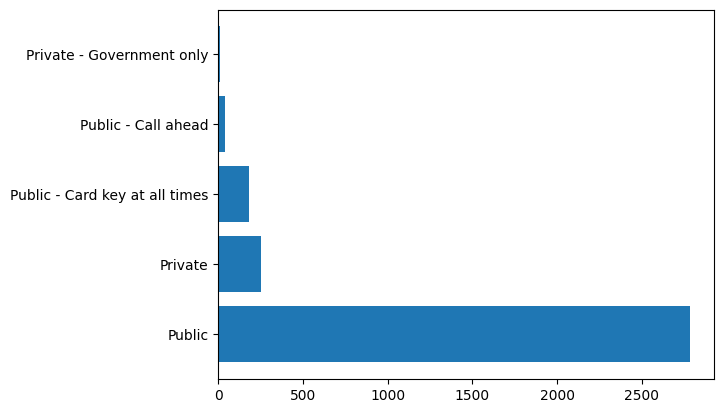

In [18]:
# bar chart of count of different types of access
plt.barh(access_counts.index, access_counts.values)
plt.show()

## 06.2 - Charger Networks

In [19]:
network_counts = chargers_new['Network'].value_counts()
network_counts

Network
ChargePoint Network    2315
Blink Network           183
eVgo Network            136
SemaCharge Network      125
Tesla Destination       116
Tesla                    65
GE WattStation           52
Non-Networked            38
Greenlots                18
OpConnect                13
EV Connect                6
Name: count, dtype: int64

<BarContainer object of 11 artists>

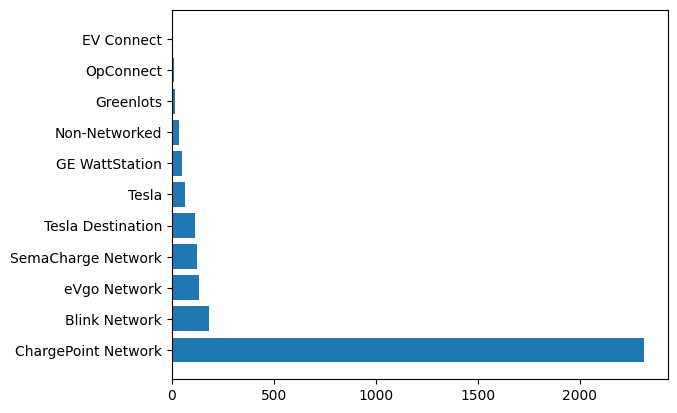

In [20]:
plt.barh(network_counts.index, network_counts.values)

## 06.3 - New stacked bar chart

In [21]:
# Change NaN to 0
chargers_new[['Level 1 charging stations',
             'Level 2 charging stations',
             'DC Fast charging stations']] = chargers_new[['Level 1 charging stations',
                                                           'Level 2 charging stations',
                                                           'DC Fast charging stations']].fillna(0)
chargers_new.head()

,Station Name,Station information,Phone number,Access,Access times,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,Network,Network website,Open date,Connections,Address,City,State,Zip code,Location 1
0,Nissan of Burlingame,NaN,650-347-4800,Public - Call ahead,NaN,0.0,1.0,0.0,NaN,NaN,01/31/2012,J1772,101 California Dr,Burlingame,CA,94010,NaN
1,BURLINGAME,LOT V 1; City parking lot V,888-758-4389,Public,24 hours daily,0.0,2.0,0.0,ChargePoint Network,http://www.chargepoint.com/,NaN,NaN,294-298 California Dr,Burlingame,CA,94010,"(37.5800222, -122.3452787)"
2,ALMAZ CAPITAL,WELCOME TO ALL; 2 stalls to the West from priv...,888-758-4389,Public,24 hours daily,0.0,2.0,0.0,ChargePoint Network,http://www.chargepoint.com/,NaN,NaN,3274 Alpine Rd,Portola Valley,CA,94028,"(37.3982219, -122.1926035)"
3,Grail Biotech,NaN,NaN,Private,NaN,0.0,2.0,0.0,NaN,NaN,11/15/2017,J1772,1525 O'Brien Dr,Menlo Park,CA,94025,NaN
4,GE WattStation,NaN,855-443-3873,Private,NaN,0.0,1.0,0.0,GE WattStation,https://www.gewattstation.com,NaN,NaN,1553 El Camino Real,Redwood City,CA,94063,"(37.4808266, -122.2274333)"


In [22]:
chargers_new_1 = chargers_new[['City',
                       'Level 1 charging stations',
                       'Level 2 charging stations',
                       'DC Fast charging stations']].copy()
chargers_new_1.head()

,City,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations
0,Burlingame,0.0,1.0,0.0
1,Burlingame,0.0,2.0,0.0
2,Portola Valley,0.0,2.0,0.0
3,Menlo Park,0.0,2.0,0.0
4,Redwood City,0.0,1.0,0.0


In [23]:
chargers_new_2 = chargers_new_1.groupby(['City']).sum()
chargers_new_2.head(10)

,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations
City,,,
Atherton,28.0,28.0,0.0
Belmont,0.0,78.0,0.0
Brisbane,0.0,26.0,20.0
Burlingame,0.0,157.0,19.0
Colma,0.0,26.0,67.0
Daly City,0.0,130.0,631.0
E. Palo Alto,0.0,42.0,0.0
East Palo Alto,0.0,33.0,260.0
Foster City,0.0,427.0,0.0


<Axes: xlabel='City'>

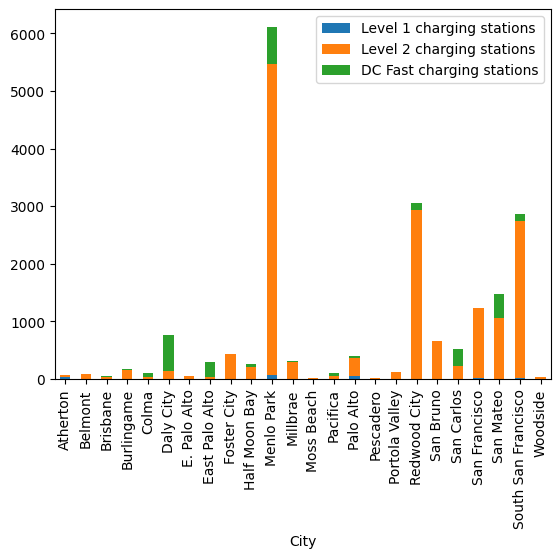

In [24]:
chargers_new_2.plot(kind='bar',stacked=True)

<Axes: xlabel='City'>

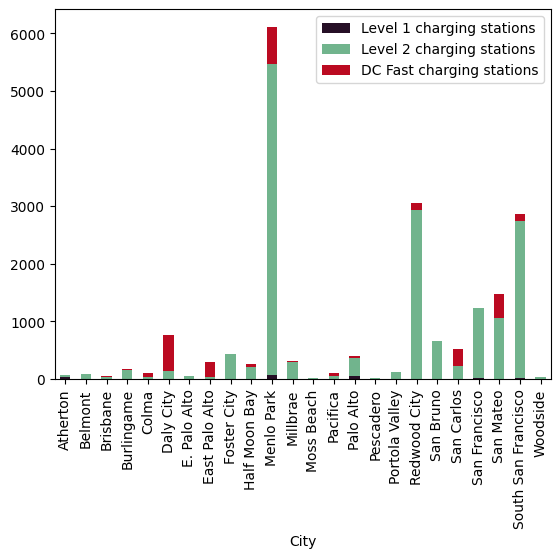

In [25]:
# Change the colors of the bars
colors = ['#260F26','#71B48D','#BB0A21']

chargers_new_2.plot(kind='bar',stacked=True,color=colors)

# 05 - Charger Types

In [26]:
# Import charger data
charger_link = 'https://raw.githubusercontent.com/veronicaj8345/DataJam/main/Electric_Vehicle_Charging_Stations_20240315.csv'
chargers = pd.read_csv(charger_link)
chargers.head()

,Station Name,Station information,Phone number,Access,Access times,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,Network,Network website,Open date,Connections,Address,City,State,Zip code,Location 1
0,Nissan of Burlingame,NaN,650-347-4800,Public - Call ahead,NaN,NaN,1.0,NaN,NaN,NaN,01/31/2012,J1772,101 California Dr,Burlingame,CA,94010,NaN
1,BURLINGAME,LOT V 1; City parking lot V,888-758-4389,Public,24 hours daily,NaN,2.0,NaN,ChargePoint Network,http://www.chargepoint.com/,NaN,NaN,294-298 California Dr,Burlingame,CA,94010,"(37.5800222, -122.3452787)"
2,ALMAZ CAPITAL,WELCOME TO ALL; 2 stalls to the West from priv...,888-758-4389,Public,24 hours daily,NaN,2.0,NaN,ChargePoint Network,http://www.chargepoint.com/,NaN,NaN,3274 Alpine Rd,Portola Valley,CA,94028,"(37.3982219, -122.1926035)"
3,Grail Biotech,NaN,NaN,Private,NaN,NaN,2.0,NaN,NaN,NaN,11/15/2017,J1772,1525 O'Brien Dr,Menlo Park,CA,94025,NaN
4,GE WattStation,NaN,855-443-3873,Private,NaN,NaN,1.0,NaN,GE WattStation,https://www.gewattstation.com,NaN,NaN,1553 El Camino Real,Redwood City,CA,94063,"(37.4808266, -122.2274333)"


I want to make a stacked bar plot of all the charger types by zip code

In [27]:
# Make tidy df of just the info I need for this
chargers_1 = chargers[['Station Name',
                       'City',
                       'Zip code',
                       'Level 1 charging stations',
                       'Level 2 charging stations',
                       'DC Fast charging stations']].copy()
chargers_1.head()

,Station Name,City,Zip code,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations
0,Nissan of Burlingame,Burlingame,94010,NaN,1.0,NaN
1,BURLINGAME,Burlingame,94010,NaN,2.0,NaN
2,ALMAZ CAPITAL,Portola Valley,94028,NaN,2.0,NaN
3,Grail Biotech,Menlo Park,94025,NaN,2.0,NaN
4,GE WattStation,Redwood City,94063,NaN,1.0,NaN


In [28]:
# Find count of each charger type by city and zip code
chargers_stacked = chargers_1.groupby(['City', 'Zip code']).sum()
chargers_stacked.head()

,,Station Name,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations
City,Zip code,,,,
Atherton,94027,Menlo CollegeMenlo CollegeMPCSDMPCSDMenlo Coll...,28.0,28.0,0.0
Belmont,94002,ORACLE RWSHOREORACLE RWSHOREORACLE RWSHOREORAC...,0.0,78.0,0.0
Brisbane,94005,BRISBANEVILLAGEBRISBANE MARINABRISBANEVILLAGEB...,0.0,26.0,20.0
Burlingame,94010,Nissan of BurlingameBURLINGAMESan Francisco Ai...,0.0,157.0,19.0
Colma,94014,Serramonte NissanNissan of SerramonteTown of C...,0.0,26.0,67.0


<Axes: xlabel='City,Zip code'>

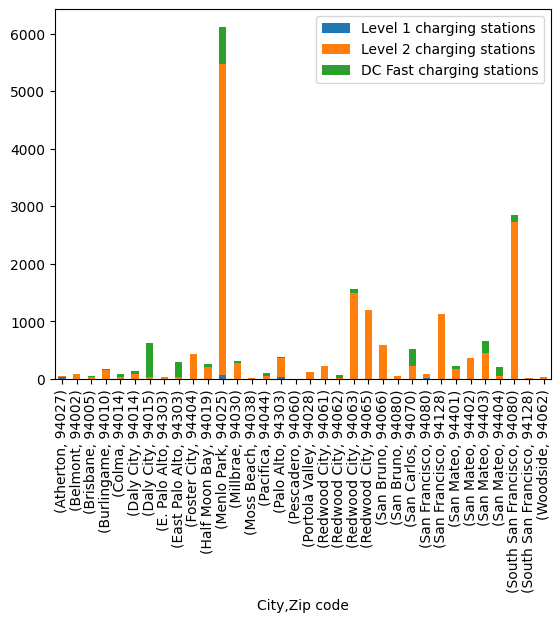

In [29]:
# Now a stacked bar chart
chargers_stacked.plot(kind='bar', stacked=True)

Can I make a chart that shows the population as a line graph in the background?

In [30]:
# Copied from 02. I just need the population data

# Pull zip code map data from my github
# Source: https://data.smcgov.org/Government/Zip-Codes-Areas/xq2v-znpu/about_data
# Map: https://data.smcgov.org/Government/Zip-Code-Areas-Map/39f7-4fdy
map = gpd.read_file("https://raw.githubusercontent.com/veronicaj8345/DataJam/main/Zip%20Codes%20-%20Areas_20240309.geojson")
map.head()

# Make tidy df of just the data I need with fixed column names
map_1 = map[['po_name', 'zip_code', 'population']].rename(columns = {'po_name':'City','zip_code':'Zip code'})

# Turn population values into integers
map_1['population'] = map_1['population'].astype('int')
map_1.head(10)

,City,Zip code,population
0,Belmont,94002,26810
1,Brisbane,94005,4538
2,Burlingame,94010,41021
3,Daly City,94014,48563
4,Daly City,94015,62539
5,El Granada,94018,754
6,Half Moon Bay,94019,19378
7,La Honda,94020,1639
8,Loma Mar,94021,160
9,Menlo Park,94025,44287


In [31]:
# Export the head as text to give to chatgpt as a sample df
df_text = map_1.head(10).to_string(index=False)
print(df_text)

         City Zip code  population
      Belmont    94002       26810
     Brisbane    94005        4538
   Burlingame    94010       41021
    Daly City    94014       48563
    Daly City    94015       62539
   El Granada    94018         754
Half Moon Bay    94019       19378
     La Honda    94020        1639
     Loma Mar    94021         160
   Menlo Park    94025       44287


In [32]:
map_1_sorted = map_1.sort_values(by='population')
map_1_sorted.head()

,City,Zip code,population
14,San Francisco,94128,69
8,Loma Mar,94021,160
31,San Gregorio,94074,347
5,El Granada,94018,754
24,Pescadero,94060,1391


In [33]:
map_1.dtypes

City          object
Zip code      object
population     int64
dtype: object

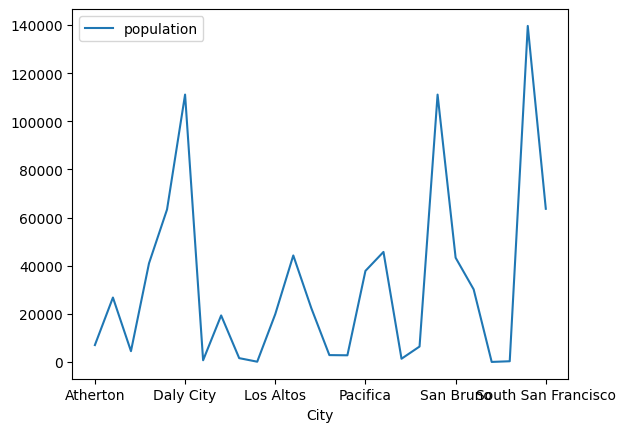

In [34]:
line_plot = map_1_sorted.groupby('City').sum().plot(kind='line')

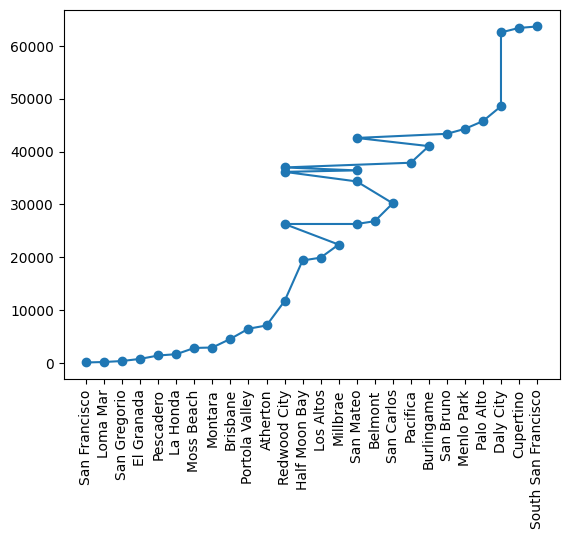

In [35]:
# map_1_sorted.plot(kind='line', x='City', marker='o')
plt.plot(map_1_sorted['City'], map_1_sorted['population'], marker='o')
plt.xticks(rotation=90)
plt.show()

[]

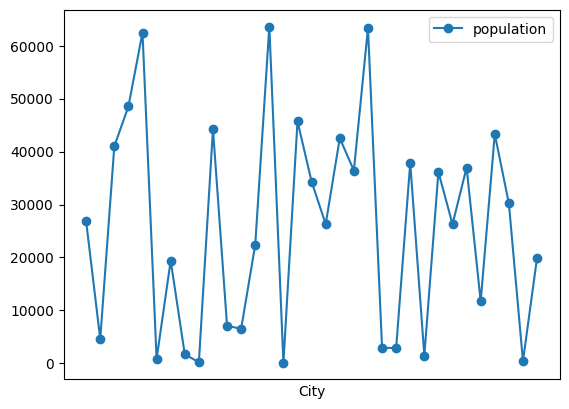

In [36]:
line_plot = map_1.plot(kind='line', x='City', marker = 'o')
line_plot.set_xticks([])

Again with the stacked bar chart

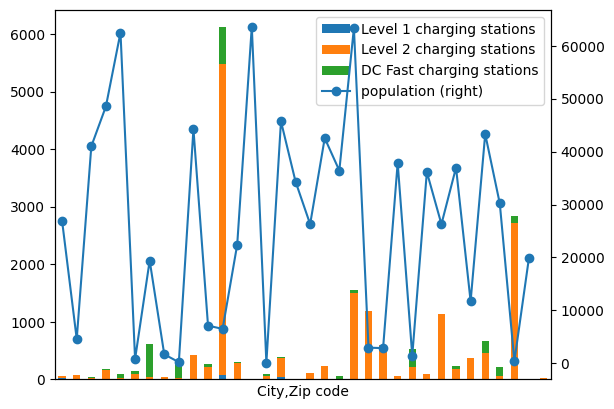

In [37]:
ax = chargers_stacked.plot(kind='bar', stacked=True)
line_plot = map_1.plot(kind='line', ax=ax, marker='o', y='population', secondary_y=True)
line_plot.set_xticks([])

plt.show()

## 05.1 - Just cities

Let's try and make this a little more simple just so I can understand it. Let's start by adding everything up just by city name

In [38]:
chargers_2 = chargers.groupby('City')['Level 1 charging stations',
                                      'Level 2 charging stations',
                                      'DC Fast charging stations'].sum()
chargers_2.head()

ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

<Axes: xlabel='City'>

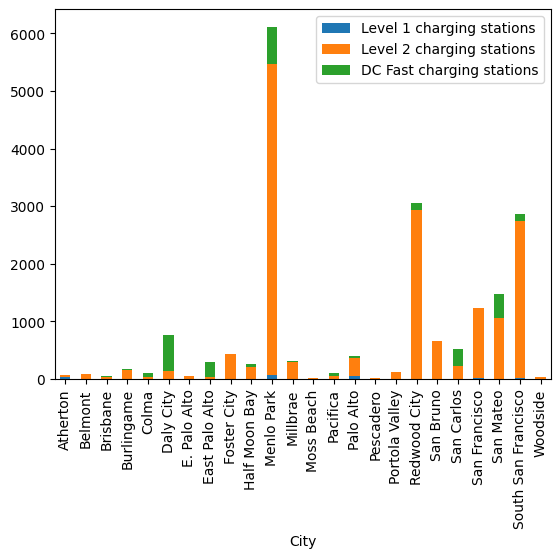

In [ ]:
chargers_2.plot(kind='bar', stacked=True)

In [ ]:
# Pull population data

map = gpd.read_file("https://raw.githubusercontent.com/veronicaj8345/DataJam/main/Zip%20Codes%20-%20Areas_20240309.geojson")
map.head()

# Make tidy df of just the data I need with fixed column names
map_1 = map[['po_name', 'zip_code', 'population']].rename(columns = {'po_name':'City'})

# Turn population values into integers
map_1['population'] = map_1['population'].astype('int')
map_1.head(10)

# Group zip codes together and convert from series to df
map_2_series = map_1.groupby('City')['population'].sum()
map_2 = map_2_series.to_frame().reset_index()
map_2.head()

,City,population
0,Atherton,7069
1,Belmont,26810
2,Brisbane,4538
3,Burlingame,41021
4,Cupertino,63392


In [ ]:
# Let's stick the dfs together so I can sort by ascending population
chargers_map_2 = pd.merge(chargers_2, map_2, on='City', how='outer')
chargers_map_2

,City,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,population
0,Atherton,28.0,28.0,0.0,7069.0
1,Belmont,0.0,78.0,0.0,26810.0
2,Brisbane,0.0,26.0,20.0,4538.0
3,Burlingame,0.0,157.0,19.0,41021.0
4,Colma,0.0,26.0,67.0,NaN
5,Daly City,0.0,130.0,631.0,111102.0
6,E. Palo Alto,0.0,42.0,0.0,NaN
7,East Palo Alto,0.0,33.0,260.0,NaN
8,Foster City,0.0,427.0,0.0,NaN
9,Half Moon Bay,0.0,211.0,50.0,19378.0


In [ ]:
# Sort based on population
chargers_map_sorted = chargers_map.sort_values(by='population')
chargers_map_sorted

,City,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,population
20,San Francisco,14.0,1207.0,0.0,69.0
27,Loma Mar,NaN,NaN,NaN,160.0
30,San Gregorio,NaN,NaN,NaN,347.0
25,El Granada,NaN,NaN,NaN,754.0
15,Pescadero,0.0,7.0,0.0,1391.0
26,La Honda,NaN,NaN,NaN,1639.0
12,Moss Beach,0.0,13.0,0.0,2821.0
29,Montara,NaN,NaN,NaN,2902.0
2,Brisbane,0.0,26.0,20.0,4538.0
16,Portola Valley,0.0,117.0,0.0,6459.0


<Axes: xlabel='City'>

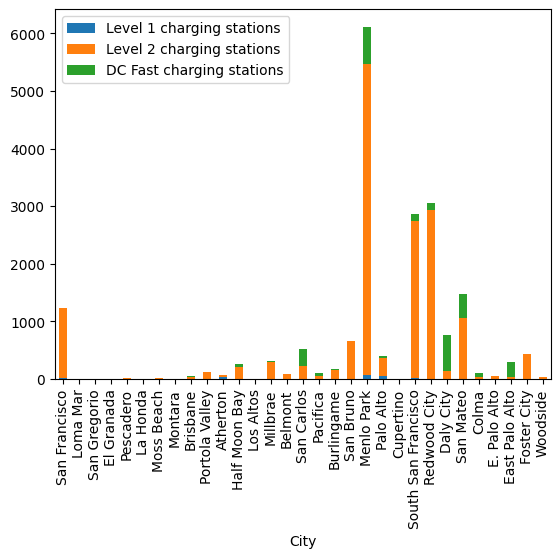

In [ ]:
chargers_map_sorted.plot(kind='bar', stacked=True, x='City', y=['Level 1 charging stations',
                                                         'Level 2 charging stations',
                                                         'DC Fast charging stations'])

In [ ]:
map_2_sorted = map_2.sort_values(by='population')
map_2_sorted

,City,population
22,San Francisco,69
9,Loma Mar,160
23,San Gregorio,347
6,El Granada,754
17,Pescadero,1391
8,La Honda,1639
14,Moss Beach,2821
13,Montara,2902
2,Brisbane,4538
18,Portola Valley,6459


<Axes: xlabel='City'>

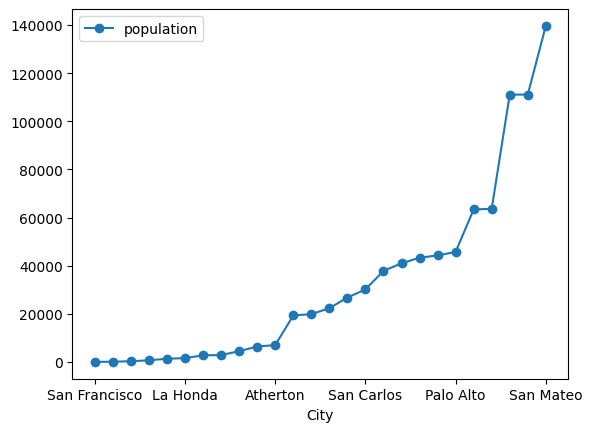

In [ ]:
map_2_sorted.plot(kind='line', x='City', marker='o')

Now let's try stacking those on top of each other

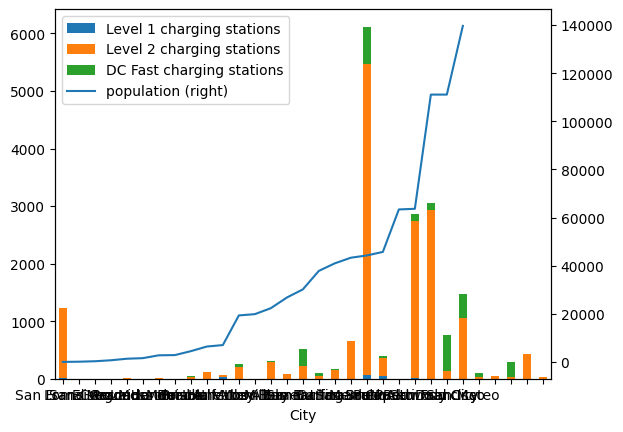

In [ ]:
# ax = chargers_stacked.plot(kind='bar', stacked=True)
# line_plot = map_1.plot(kind='line', ax=ax, marker='o', y='population', secondary_y=True)

ax = chargers_map_sorted.plot(kind='bar',
                              stacked=True,
                              x='City',
                              y=['Level 1 charging stations',
                                 'Level 2 charging stations',
                                 'DC Fast charging stations'])
line_plot = map_2_sorted.plot(kind='line', ax=ax, x='City', secondary_y=True)
line_plot.set_xticks([])
ax.set_xticks(chargers_map_sorted.index)

plt.show()

That's almost what I want but I can't fix the x axis labels. Let's try this another way

In [ ]:
chargers_map_sorted['']

City                          object
Level 1 charging stations    float64
Level 2 charging stations    float64
DC Fast charging stations    float64
population                   float64
dtype: object

In [ ]:
chargers_map_sorted.head()

,City,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,population
20,San Francisco,14.0,1207.0,0.0,69.0
27,Loma Mar,NaN,NaN,NaN,160.0
30,San Gregorio,NaN,NaN,NaN,347.0
25,El Granada,NaN,NaN,NaN,754.0
15,Pescadero,0.0,7.0,0.0,1391.0


In [ ]:
# # Plotting the stacked bar chart
# df.set_index('Category')[['Value 1', 'Value 2', 'Value 3']].plot(kind='bar', stacked=True)

# # Plotting the line plot
# plt.plot(df['Category'], df['Line Values'], color='red', marker='o', label='Line Values')

# # Rotate the x-axis tick labels
# plt.xticks(rotation=90)

# # Adding legend
# plt.legend()

# plt.show()

chargers_map_sorted.set_index('City'[['Level 1 charging stations',
                                      'Level 2 charging stations',
                                      'DC Fast charging stations']]).plot(kind='bar', stacked=True)

<>:15: SyntaxWarning: str indices must be integers or slices, not list; perhaps you missed a comma?
<>:15: SyntaxWarning: str indices must be integers or slices, not list; perhaps you missed a comma?
<ipython-input-82-b5546d27d8b7>:15: SyntaxWarning: str indices must be integers or slices, not list; perhaps you missed a comma?
  chargers_map_sorted.set_index('City'[['Level 1 charging stations',


TypeError: string indices must be integers

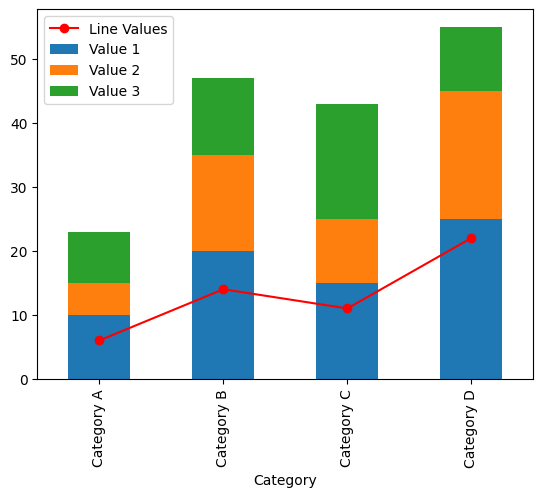

In [ ]:
# ChatGPT example
import pandas as pd
import matplotlib.pyplot as plt

# Sample data
data = {
    'Category': ['Category A', 'Category B', 'Category C', 'Category D'],
    'Value 1': [10, 20, 15, 25],
    'Value 2': [5, 15, 10, 20],
    'Value 3': [8, 12, 18, 10],
    'Line Values': [6, 14, 11, 22]
}

# Creating DataFrame
df = pd.DataFrame(data)

# Plotting the stacked bar chart
df.set_index('Category')[['Value 1', 'Value 2', 'Value 3']].plot(kind='bar', stacked=True)

# Plotting the line plot
plt.plot(df['Category'], df['Line Values'], color='red', marker='o', label='Line Values')

# Rotate the x-axis tick labels
plt.xticks(rotation=90)

# Adding legend
plt.legend()

plt.show()



## 05.2 - Zip codes

There seems to be some gaps in the data. Let's see what zip codes are left out

In [ ]:
# Pull population data

map = gpd.read_file("https://raw.githubusercontent.com/veronicaj8345/DataJam/main/Zip%20Codes%20-%20Areas_20240309.geojson")
map.head()

# Make tidy df of just the data I need with fixed column names
map_1 = map[['po_name', 'zip_code', 'population']].rename(columns = {'po_name':'City', 'zip_code':'Zip code'})

# Turn population values into integers
map_1['population'] = map_1['population'].astype('int')
map_1.head(10)


,City,Zip code,population
0,Belmont,94002,26810
1,Brisbane,94005,4538
2,Burlingame,94010,41021
3,Daly City,94014,48563
4,Daly City,94015,62539
5,El Granada,94018,754
6,Half Moon Bay,94019,19378
7,La Honda,94020,1639
8,Loma Mar,94021,160
9,Menlo Park,94025,44287


In [ ]:
chargers_3 = chargers.groupby('Zip code')['Level 1 charging stations',
                                      'Level 2 charging stations',
                                      'DC Fast charging stations'].sum().astype('int').reset_index()

# Turn zip code values into objects
chargers_3['Zip code'] = chargers_3['Zip code'].astype('str')
chargers_3.head()

<ipython-input-6-026543bbe982>:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  chargers_3 = chargers.groupby('Zip code')['Level 1 charging stations',


,Zip code,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations
0,94002,0,78,0
1,94005,0,26,20
2,94010,0,157,19
3,94014,0,117,117
4,94015,0,39,581


In [ ]:
chargers_3.dtypes

Zip code                     object
Level 1 charging stations     int64
Level 2 charging stations     int64
DC Fast charging stations     int64
dtype: object

In [ ]:
map_1.dtypes

City          object
Zip code      object
population     int64
dtype: object

In [ ]:
chargers_map_3 = pd.merge(chargers_3, map_1, on='Zip code', how='outer')
chargers_map_3

,Zip code,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,City,population
0,94002,0.0,78.0,0.0,Belmont,26810
1,94005,0.0,26.0,20.0,Brisbane,4538
2,94010,0.0,157.0,19.0,Burlingame,41021
3,94014,0.0,117.0,117.0,Daly City,48563
4,94015,0.0,39.0,581.0,Daly City,62539
5,94019,0.0,211.0,50.0,Half Moon Bay,19378
6,94025,73.0,5402.0,641.0,Menlo Park,44287
7,94027,28.0,28.0,0.0,Atherton,7069
8,94028,0.0,117.0,0.0,Portola Valley,6459
9,94030,0.0,284.0,21.0,Millbrae,22386


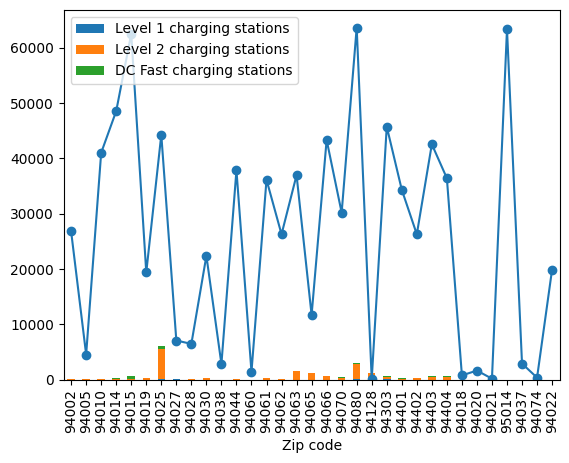

In [ ]:
# # Plotting the stacked bar chart
# df.set_index('Category')[['Value 1', 'Value 2', 'Value 3']].plot(kind='bar', stacked=True)

# # Plotting the line plot
# plt.plot(df['Category'], df['Line Values'], color='red', marker='o', label='Line Values')

chargers_map_3.set_index('Zip code')[['Level 1 charging stations',
                                     'Level 2 charging stations',
                                     'DC Fast charging stations']].plot(kind='bar', stacked=True)

plt.plot(chargers_map_3['Zip code'], chargers_map_3['population'], marker='o', label='Population')

## 05.3 - Map of count of chargers

In [ ]:
# Sum the total number of chargers to make the map
chargers_3['Total Chargers'] = chargers_3['Level 1 charging stations'] + chargers_3['Level 2 charging stations'] + chargers_3['DC Fast charging stations']
chargers_3.head()

,Zip code,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,Total Chargers
0,94002,0,78,0,78
1,94005,0,26,20,46
2,94010,0,157,19,176
3,94014,0,117,117,234
4,94015,0,39,581,620


In [ ]:
map.head()

,zip_code,pop_sqmi,sqmi,population,po_name,geometry
0,94002,4662.61,5.75,26810,Belmont,"MULTIPOLYGON (((-122.26821 37.52822, -122.2681..."
1,94005,896.84,5.06,4538,Brisbane,"MULTIPOLYGON (((-122.39114 37.69319, -122.3909..."
2,94010,3179.92,12.9,41021,Burlingame,"MULTIPOLYGON (((-122.33304 37.58786, -122.3332..."
3,94014,8203.21,5.92,48563,Daly City,"MULTIPOLYGON (((-122.40826 37.70235, -122.4083..."
4,94015,11207.71,5.58,62539,Daly City,"MULTIPOLYGON (((-122.46628 37.66991, -122.4662..."


In [ ]:
map_2 = pd.merge(map, chargers_3, left_on='zip_code', right_on='Zip code', how="outer")
map_2.head()

,zip_code,pop_sqmi,sqmi,population,po_name,geometry,Zip code,Level 1 charging stations,Level 2 charging stations,DC Fast charging stations,Total Chargers
0,94002,4662.61,5.75,26810,Belmont,"MULTIPOLYGON (((-122.26821 37.52822, -122.2681...",94002,0.0,78.0,0.0,78.0
1,94005,896.84,5.06,4538,Brisbane,"MULTIPOLYGON (((-122.39114 37.69319, -122.3909...",94005,0.0,26.0,20.0,46.0
2,94010,3179.92,12.9,41021,Burlingame,"MULTIPOLYGON (((-122.33304 37.58786, -122.3332...",94010,0.0,157.0,19.0,176.0
3,94014,8203.21,5.92,48563,Daly City,"MULTIPOLYGON (((-122.40826 37.70235, -122.4083...",94014,0.0,117.0,117.0,234.0
4,94015,11207.71,5.58,62539,Daly City,"MULTIPOLYGON (((-122.46628 37.66991, -122.4662...",94015,0.0,39.0,581.0,620.0


In [ ]:
map_2['Total Chargers'] = map_2['Total Chargers'].astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

KeyError: 'Total Chargers'

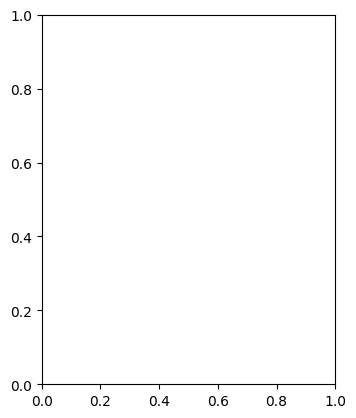

In [ ]:
map.plot(column = 'Total Chargers', legend=True)
plt.title("San Mateo County Total Chargers per Zip Code")
plt.show()

# 04 - March 14

In [ ]:
# Group together fuel types into different categories
# First up: Traditional VS Alternative Fuel

# Make a directory where the keys are the Fuel types and the values are Traditional, Alternative or Other
fuel_group_1 = {'Gasoline':'Traditional',
                'Hybrid Gasoline':'Alternative',
                'Battery Electric':'Alternative',
                'Flex-Fuel':'Alternative',
                'Diesel and Diesel Hybrid':'Traditional',
                'Unk':'Other',
                'Plug-in Hybrid':'Alternative',
                'Hydrogen Fuel Cell':'Alternative',
                'Natural Gas':'Alternative',
                'Other':'Other'}

cars_SMC['Group'] = cars_SMC['Fuel'].map(fuel_group_1)
cars_SMC                                                                                                                                                                                                                                                                                                                 # Map variable and assign output to new variable. Add up by Group and assign to new dataframe
                                                                                                                                                                           #fuel_SMC_1_data = fuel_SMC.assign(Group = fuel_SMC.Fuel.map(fuel_group_1))
                                                                                                                                                                          # fuel_SMC_1_data
                                                                                                                                                                           # Do this next part if you want a tidyier dataframe of just trad/alt/other. Keep as is for stacked bar plot
                                                                                                                                                                           # fuel_SMC_1_data = fuel_SMC_1_data.groupby('Group').Count.sum()

                                                                                                                                                                           # fuel_SMC_1 = pd.DataFrame(data=fuel_SMC_1_data).reset_index()
                                                                                                                                                                           # fuel_SMC_1.columns = ["Group", "Count"]
                                                                                                                                                                           # fuel_SMC_1

,Date,Zip Code,Model Year,Fuel,Make,Duty,Vehicles,City,Group
0,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Heavy,2,Belmont,Traditional
1,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Light,65,Belmont,Traditional
2,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Unk,25,Belmont,Traditional
3,12/31/2022,94002,2008,Gasoline,FORD,Light,33,Belmont,Traditional
4,12/31/2022,94002,2008,Gasoline,CHEVROLET,Light,11,Belmont,Traditional
...,...,...,...,...,...,...,...,...,...
19451,12/31/2022,94405,2015,Gasoline,OTHER/UNK,Light,2,San Mateo,Traditional
19452,12/31/2022,94407,2011,Gasoline,OTHER/UNK,Light,1,San Mateo,Traditional
19453,12/31/2022,94407,2014,Gasoline,OTHER/UNK,Light,1,San Mateo,Traditional
19454,12/31/2022,94407,<2009,Gasoline,OTHER/UNK,Light,3,San Mateo,Traditional


In [ ]:
# Find ratio of alt to trad by zip code
cars_SMC_2 = cars_SMC.pivot_table(index = ['City', 'Zip Code'],
                            columns = 'Group',
                            values = 'Vehicles',
                            aggfunc = 'sum').reset_index()
cars_SMC_2['Ratio'] = cars_SMC_2['Alternative'] / cars_SMC_2['Traditional']
cars_SMC_2

Group,City,Zip Code,Alternative,Other,Traditional,Ratio
0,Airport Mail Center,94128,175.0,8.0,455.0,0.384615
1,Atherton,94027,1506.0,234.0,4629.0,0.325340
2,Belmont,94002,4221.0,459.0,17089.0,0.247001
3,Belmont,94003,2.0,NaN,18.0,0.111111
4,Brisbane,94005,809.0,109.0,3546.0,0.228144
5,Burlingame,94010,7199.0,884.0,27868.0,0.258325
6,Burlingame,94011,55.0,30.0,412.0,0.133495
7,Colma,94014,4038.0,457.0,27087.0,0.149075
8,Daly City,94014,4038.0,457.0,27087.0,0.149075
9,Daly City,94015,6301.0,481.0,35224.0,0.178884


In [ ]:
cars_SMC_2['Zip Code'] = cars_SMC_2['Zip Code'].astype(str)

In [ ]:
# Try mapping ratio of alt fuel to trad fuel by zip code
map_ratio = pd.merge(cars_SMC_2[['Zip Code', 'Ratio']],
                     map[['zip_code', 'population', 'po_name', 'geometry']],
                     left_on='Zip Code',
                     right_on='zip_code',
                     how='inner')

map_ratio.drop(columns=['zip_code'], inplace=True)
map_ratio

TypeError: 'type' object is not subscriptable

In [ ]:
map_ratio.dtypes

NameError: name 'map_ratio' is not defined

In [ ]:
map_ratio.set_geometry('geometry')

NameError: name 'map_ratio' is not defined

<Axes: >

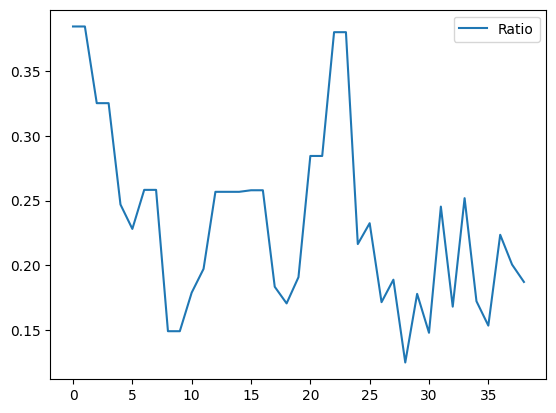

In [ ]:
map_ratio.plot()

# 03 - Income Dataset

## 03.1 - Convert income df from percentages to counts

In [ ]:
# Pull income data (with distribution data stored as percentages)
income_link = "https://raw.githubusercontent.com/edenmhuang/DataJam_2024/main/CA_Household_Income_2022.csv"
income_SMC = pd.read_csv(income_link)
income_SMC.head()

,Zip Code,Total Households,"Less than $10,000","$10,000 to $14,999","$15,000 to $24,999","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999","$100,000 to $149,999","$150,000 to $199,999","$200,000 or more",Median income (dollars),Mean income (dollars)
0,94002,10854,2.5%,3.5%,3.3%,2.8%,3.0%,7.2%,5.3%,13.3%,11.1%,48.0%,184929,238074
1,94005,1902,3.3%,0.0%,1.6%,0.0%,14.4%,10.9%,7.8%,16.1%,9.3%,36.6%,137583,252170
2,94010,16070,2.8%,0.8%,2.3%,2.5%,4.5%,7.7%,7.4%,12.6%,12.3%,47.1%,186198,297111
3,94014,14014,3.7%,3.3%,5.2%,5.0%,7.6%,9.6%,11.4%,19.0%,16.4%,18.9%,111795,134129
4,94015,20476,3.5%,2.1%,3.9%,4.1%,5.5%,10.3%,12.7%,20.2%,13.4%,24.3%,117289,147777


In [ ]:
# Fix columns - Simply names, convert percentages to floats
# Rename all columns
income_columns = ['Zip Code',
                  'Total Households',
                  '$0 - $10k',
                  '$10k - $15k',
                  '$15k - $25k',
                  '$25k - $35k',
                  '$35k - $50k',
                  '$50k - $75k',
                  '$75k - $100k',
                  '$100k - $150k',
                  '$150k - $200k',
                  '$200k+',
                  'Median Income',
                  'Mean Income']

income_SMC.columns = income_columns

# Convert percentage columns to floats
percentage_columns = ['$0 - $10k',
                      '$10k - $15k',
                      '$15k - $25k',
                      '$25k - $35k',
                      '$35k - $50k',
                      '$50k - $75k',
                      '$75k - $100k',
                      '$100k - $150k',
                      '$150k - $200k',
                      '$200k+']

for col in percentage_columns:
    income_SMC[col] = income_SMC[col].str.rstrip('%').astype('float') / 100

In [ ]:
income_SMC.dtypes

Zip Code              int64
Total Households      int64
$0 - $10k           float64
$10k - $15k         float64
$15k - $25k         float64
$25k - $35k         float64
$35k - $50k         float64
$50k - $75k         float64
$75k - $100k        float64
$100k - $150k       float64
$150k - $200k       float64
$200k+              float64
Median Income         int64
Mean Income           int64
dtype: object

In [ ]:
income_SMC_counts = income_SMC.copy()

In [ ]:
# Calculate counts for each income bracket and convert to int64 to round
for col in percentage_columns:
  income_SMC_counts[col] = income_SMC_counts['Total Households'] * income_SMC_counts[col]

In [ ]:
# Convert to integer
for col in percentage_columns:
  income_SMC_counts[col] = income_SMC_counts[col].astype('int64')

In [ ]:
income_SMC_counts.head()

,Unnamed: 0,Zip Code,Total Households,$0 - $10k,$10k - $15k,$15k - $25k,$25k - $35k,$35k - $50k,$50k - $75k,$75k - $100k,$100k - $150k,$150k - $200k,$200k+,Median Income,Mean Income
0,0,94002,10854,271,379,358,303,325,781,575,1443,1204,5209,184929,238074
1,1,94005,1902,62,0,30,0,273,207,148,306,176,696,137583,252170
2,2,94010,16070,449,128,369,401,723,1237,1189,2024,1976,7568,186198,297111
3,3,94014,14014,518,462,728,700,1065,1345,1597,2662,2298,2648,111795,134129
4,4,94015,20476,716,429,798,839,1126,2109,2600,4136,2743,4975,117289,147777


In [ ]:
# Export as CSV
income_SMC_counts.to_csv('income_SMC_counts.csv', index=False)

## 03.2 - Plot income distribution

In [ ]:
# Pull cleaned income df
income_counts_link = "https://raw.githubusercontent.com/veronicaj8345/DataJam/main/income_SMC_counts.csv"
income_SMC_counts = pd.read_csv(income_counts_link)
income_SMC_counts

,Zip Code,Total Households,$0 - $10k,$10k - $15k,$15k - $25k,$25k - $35k,$35k - $50k,$50k - $75k,$75k - $100k,$100k - $150k,$150k - $200k,$200k+,Median Income,Mean Income
0,94002,10854,271,379,358,303,325,781,575,1443,1204,5209,184929,238074
1,94005,1902,62,0,30,0,273,207,148,306,176,696,137583,252170
2,94010,16070,449,128,369,401,723,1237,1189,2024,1976,7568,186198,297111
3,94014,14014,518,462,728,700,1065,1345,1597,2662,2298,2648,111795,134129
4,94015,20476,716,429,798,839,1126,2109,2600,4136,2743,4975,117289,147777
5,94018,1366,0,16,12,40,106,72,75,210,64,767,215439,247313
6,94019,5548,149,116,116,194,305,349,399,1176,699,2041,149655,214468
7,94020,844,32,0,43,10,0,37,27,47,30,616,250000,269305
8,94021,61,0,0,0,0,0,0,0,0,10,50,201950,308830
9,94025,14349,301,186,286,401,660,903,803,1965,1564,7274,207656,324294


In [ ]:
# Set Zip Code to string bc it's a categorical variable

income_SMC_counts['Zip Code'] = income_SMC_counts['Zip Code'].astype(str)

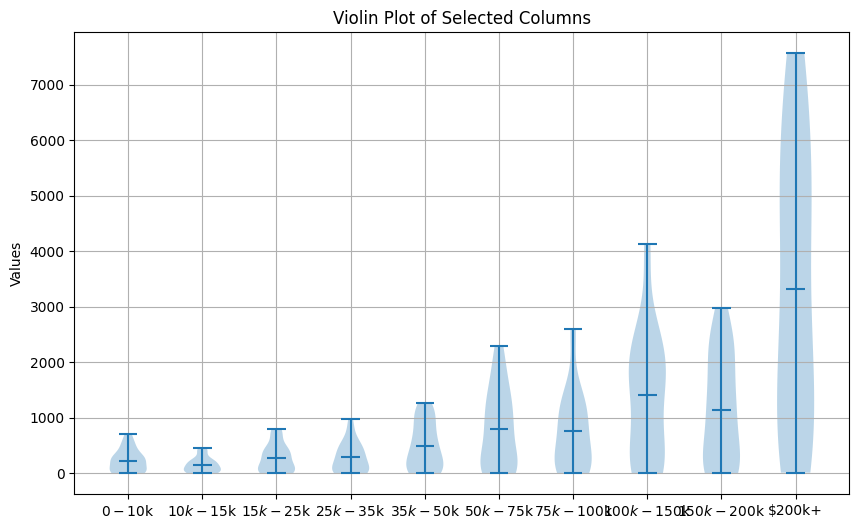

In [ ]:
# Drop the columns you don't want to include
columns_to_exclude = ['Zip Code', 'Total Households', 'Median Income', 'Mean Income']  # Replace with columns you want to exclude
data_to_plot = income_SMC_counts.drop(columns_to_exclude, axis=1)

# Create a violin plot
plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
plt.violinplot(data_to_plot.values, showmeans=True)  # Show means as points inside violins
plt.xticks(range(1, data_to_plot.shape[1] + 1), data_to_plot.columns)  # Set x-axis labels
plt.ylabel('Values')  # Set y-axis label
plt.title('Violin Plot of Selected Columns')  # Set plot title
plt.grid(True)  # Add grid for better readability
plt.show()

In [ ]:
# Try making a barplot bc the income brackets are categorical
sns.barplot(x='')

TypeError: bar() missing 1 required positional argument: 'height'

In [ ]:
import pandas as pd
import json

# Assuming df is your DataFrame
head_as_dict = income_SMC_counts.head().to_dict(orient='list')

# Convert to JSON string
head_json = json.dumps(head_as_dict)

# To replicate the DataFrame with the head, you can use the following code:
# head_json will contain the head information in JSON format
# You can use this JSON string to recreate the DataFrame with the head included

# Example:
# head_json = '{"Column1": [value1, value2, value3, value4, value5], "Column2": [value1, value2, value3, value4, value5], ...}'

# Recreating DataFrame with the head
# df = pd.DataFrame(json.loads(head_json))



In [ ]:
head_json

'{"Zip Code": ["94002", "94005", "94010", "94014", "94015"], "Total Households": [10854, 1902, 16070, 14014, 20476], "$0 - $10k": [271, 62, 449, 518, 716], "$10k - $15k": [379, 0, 128, 462, 429], "$15k - $25k": [358, 30, 369, 728, 798], "$25k - $35k": [303, 0, 401, 700, 839], "$35k - $50k": [325, 273, 723, 1065, 1126], "$50k - $75k": [781, 207, 1237, 1345, 2109], "$75k - $100k": [575, 148, 1189, 1597, 2600], "$100k - $150k": [1443, 306, 2024, 2662, 4136], "$150k - $200k": [1204, 176, 1976, 2298, 2743], "$200k+": [5209, 696, 7568, 2648, 4975], "Median Income": [184929, 137583, 186198, 111795, 117289], "Mean Income": [238074, 252170, 297111, 134129, 147777]}'

## 03.3 - Long data format




ChatGPT example

In [ ]:
import pandas as pd

# Sample data
data = {
    'Zip Code': [94002],
    'Total Households': [10854],
    '$0 - $10k': [271],
    '$10k - $15k': [379],
    '$15k - $25k': [358],
    '$25k - $35k': [303],
    '$35k - $50k': [325],
    '$50k - $75k': [781],
    '$75k - $100k': [575],
    '$100k - $150k': [1443],
    '$150k - $200k': [1204],
    '$200k+': [5209],
    'Median Income': [184929],
    'Mean Income': [238074]
}

# Create DataFrame
df = pd.DataFrame(data)

# Create a list of income brackets
income_brackets = ['$0 - $10k', '$10k - $15k', '$15k - $25k', '$25k - $35k', '$35k - $50k',
                   '$50k - $75k', '$75k - $100k', '$100k - $150k', '$150k - $200k', '$200k+']

# Initialize an empty list to hold the long format data
long_data = []

# Iterate over each row in the DataFrame
for index, row in df.iterrows():
    zip_code = row['Zip Code']
    total_households = row['Total Households']
    # Iterate over each income bracket
    for bracket in income_brackets:
        # Extract the number of households in the current bracket
        households_in_bracket = row[bracket]
        # Append a row to the long format data for each household in the current bracket
        for i in range(households_in_bracket):
            long_data.append({'Zip Code': zip_code, 'Household': i+1, 'Income Bracket': bracket})

# Create a DataFrame from the long format data
long_df = pd.DataFrame(long_data)

# Print the first few rows of the long format DataFrame
print(long_df.head())


   Zip Code  Household Income Bracket
0     94002          1      $0 - $10k
1     94002          2      $0 - $10k
2     94002          3      $0 - $10k
3     94002          4      $0 - $10k
4     94002          5      $0 - $10k


<ipython-input-33-b7beea8c4f13>:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="Income Bracket", y="Zip Code", data=long_df, scale="width", inner="quartile")


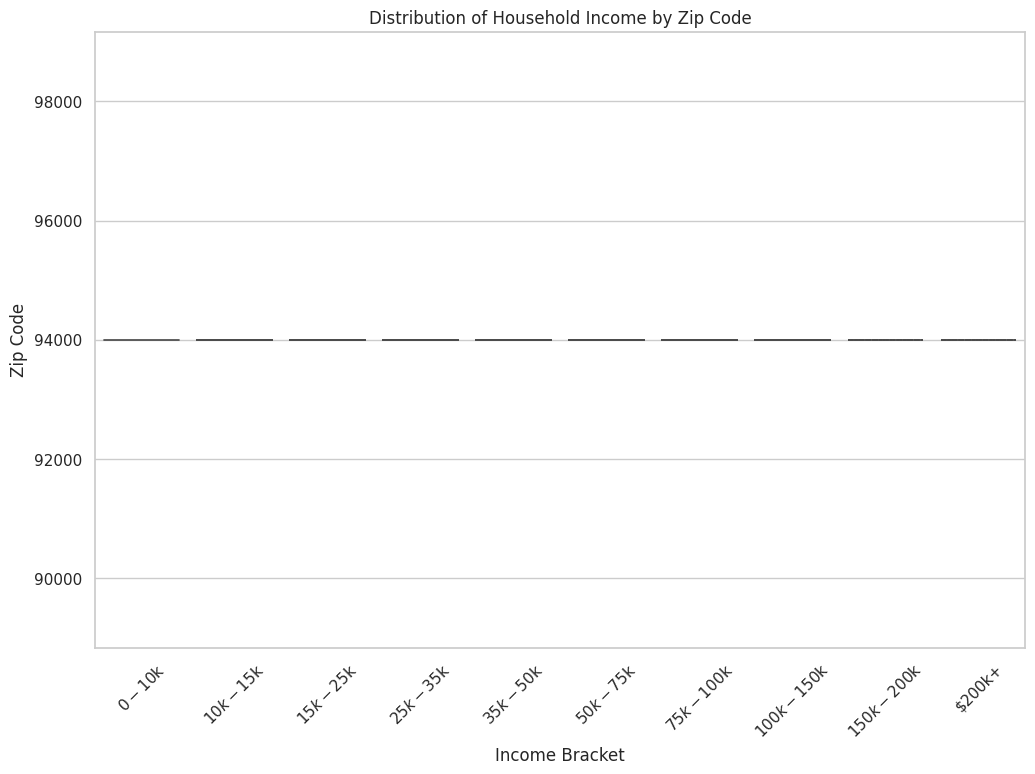

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style of the plot
sns.set(style="whitegrid")

# Create the violin plot
plt.figure(figsize=(12, 8))
sns.violinplot(x="Income Bracket", y="Zip Code", data=long_df, scale="width", inner="quartile")

# Set the title and labels
plt.title('Distribution of Household Income by Zip Code')
plt.xlabel('Income Bracket')
plt.ylabel('Zip Code')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()


In [ ]:
plot_df.head(10)

,Zip Code,Household,Income Bracket,Representative Income
0,94002,1,$0 - $10k,898.389037
1,94002,2,$0 - $10k,2361.219850
2,94002,3,$0 - $10k,4198.164230
3,94002,4,$0 - $10k,7769.360105
4,94002,5,$0 - $10k,2539.569182
5,94002,6,$0 - $10k,7842.137923
6,94002,7,$0 - $10k,2843.986396
7,94002,8,$0 - $10k,7077.906018
8,94002,9,$0 - $10k,2216.191576
9,94002,10,$0 - $10k,3360.924359


<ipython-input-40-eafca537b586>:35: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x="Income Bracket", y="Representative Income", data=plot_df, scale="width", inner="quartile")


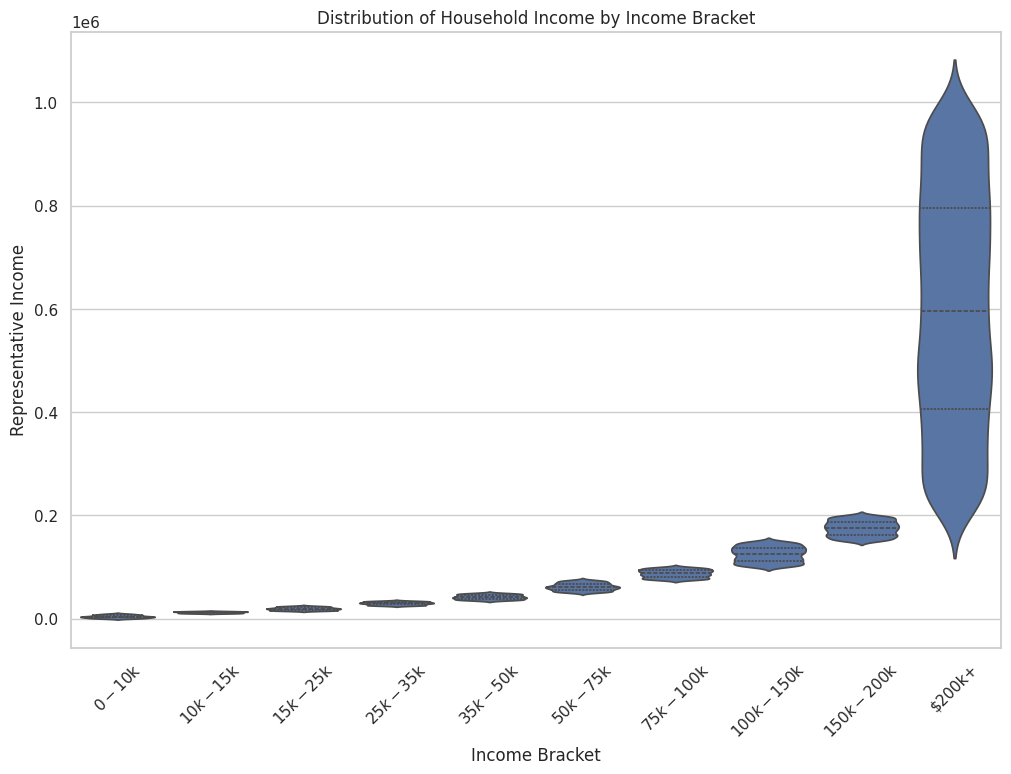

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set the style of the plot
sns.set(style="whitegrid")

# Create a copy of the long format DataFrame
plot_df = long_df.copy()

# Define income ranges for each bracket
income_ranges = {
    '$0 - $10k': (0, 10000),
    '$10k - $15k': (10000, 15000),
    '$15k - $25k': (15000, 25000),
    '$25k - $35k': (25000, 35000),
    '$35k - $50k': (35000, 50000),
    '$50k - $75k': (50000, 75000),
    '$75k - $100k': (75000, 100000),
    '$100k - $150k': (100000, 150000),
    '$150k - $200k': (150000, 200000),
    '$200k+': (200000, 1000000)
}

# Add a column for representative household income
representative_incomes = []
for bracket in plot_df['Income Bracket']:
    lower_bound, upper_bound = income_ranges[bracket]
    representative_incomes.append(np.random.uniform(lower_bound, upper_bound))

plot_df['Representative Income'] = representative_incomes

# Create the violin plot
plt.figure(figsize=(12, 8))
sns.violinplot(x="Income Bracket", y="Representative Income", data=plot_df, scale="width", inner="quartile")

# Set the title and labels
plt.title('Distribution of Household Income by Income Bracket')
plt.xlabel('Income Bracket')
plt.ylabel('Representative Income')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()


## 03.4 - Prepare simplified example dataset

There's gotta be a better way to do this. Let's make a sample df for ChatGPT

In [ ]:
simple_data = {
    '1-5':[2],
    '6-10':[1],
    '11-15':[3],
    '16-20':[4]
}
simple_df = pd.DataFrame(simple_data)

simple_data_long = {
    "Household":['1','2','3','4','5','6','7','8','9','10'],
    "Number":[2,1,7,12,14,13,16,17,18,19],
    "Range":['1-5','1-5','6-10','11-15','11-15','11-15','16-20','16-20','16-20','16-20']
}
simple_df_long = pd.DataFrame(simple_data_long)

In [ ]:
simple_df

,1-5,6-10,11-15,16-20
0,2,1,3,4


In [ ]:
simple_df_long

,Household,Number,Range,RangeNumeric
0,1,2,1-5,3
1,2,4,1-5,3
2,3,7,6-10,8
3,4,12,11-15,13
4,5,14,11-15,13
5,6,13,11-15,13
6,7,16,16-20,18
7,8,17,16-20,18
8,9,18,16-20,18
9,10,19,16-20,18


<Axes: ylabel='Number'>

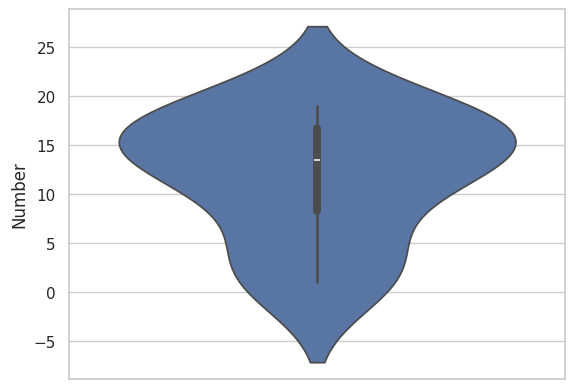

In [ ]:
sns.violinplot(y="Number", data=simple_df_long)

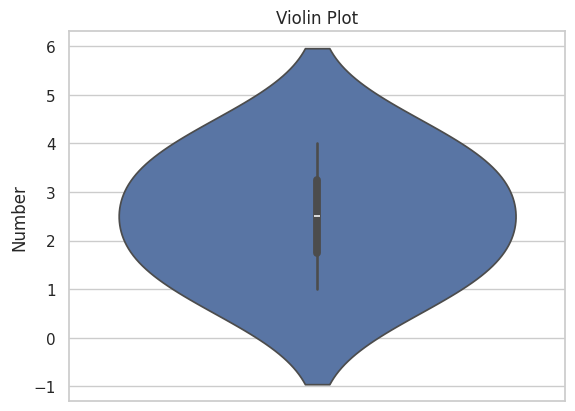

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Your data
simple_data = {
    '1-5':[2],
    '6-10':[1],
    '11-15':[3],
    '16-20':[4]
}
simple_df = pd.DataFrame(simple_data)

# Transpose the DataFrame to convert it to long format
simple_df_long1 = simple_df.melt(var_name='Range', value_name='Number')

# Create violin plot
sns.violinplot(y="Number", data=simple_df_long1)

# Show plot
plt.title('Violin Plot')
plt.show()


In [ ]:
simple_df_long1

,Range,Number
0,1-5,2
1,6-10,1
2,11-15,3
3,16-20,4


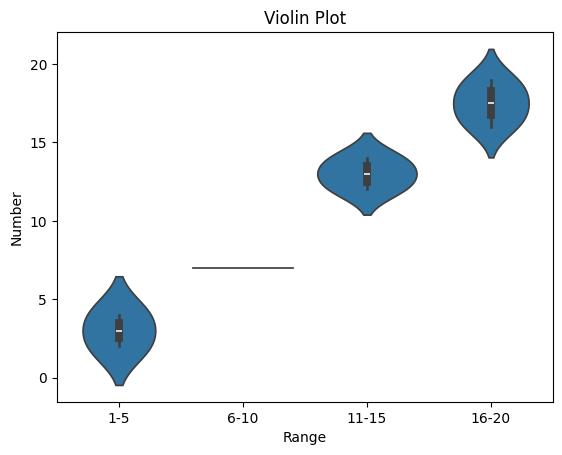

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Your data
simple_data_long = {
    "Household":['1','2','3','4','5','6','7','8','9','10'],
    "Number":[2,4,7,12,14,13,16,17,18,19],
    "Range":['1-5','1-5','6-10','11-15','11-15','11-15','16-20','16-20','16-20','16-20']
}
simple_df_long = pd.DataFrame(simple_data_long)

# Map range values to numeric values
range_mapping = {'1-5': 3, '6-10': 8, '11-15': 13, '16-20': 18}
simple_df_long['RangeNumeric'] = simple_df_long['Range'].map(range_mapping)

# Create violin plot
sns.violinplot(x="RangeNumeric", y="Number", data=simple_df_long)

# Show plot
plt.xticks(ticks=range(len(range_mapping)), labels=range_mapping.keys())
plt.xlabel('Range')
plt.ylabel('Number')
plt.title('Violin Plot')
plt.show()


In [ ]:
simple_df_long

,Household,Number,Range,RangeNumeric
0,1,2,1-5,3
1,2,4,1-5,3
2,3,7,6-10,8
3,4,12,11-15,13
4,5,14,11-15,13
5,6,13,11-15,13
6,7,16,16-20,18
7,8,17,16-20,18
8,9,18,16-20,18
9,10,19,16-20,18


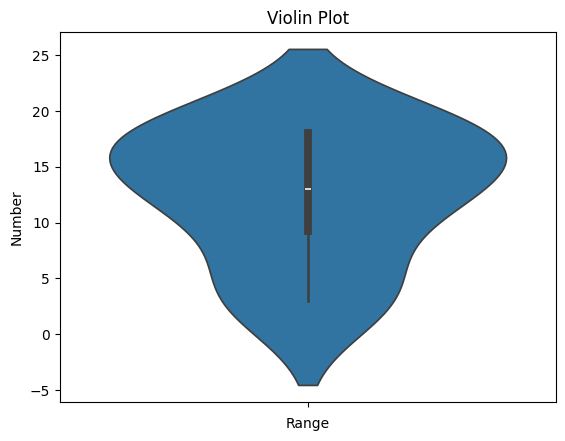

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Your data
simple_data_long = {
    "Household":['1','2','3','4','5','6','7','8','9','10'],
    "Number":[2,4,7,12,14,13,16,17,18,19],
    "Range":['1-5','1-5','6-10','11-15','11-15','11-15','16-20','16-20','16-20','16-20']
}
simple_df_long = pd.DataFrame(simple_data_long)

# Map range values to numeric values
range_mapping = {'1-5': 3, '6-10': 8, '11-15': 13, '16-20': 18}
simple_df_long['RangeNumeric'] = simple_df_long['Range'].map(range_mapping)

# Create violin plot
sns.violinplot(y="RangeNumeric", data=simple_df_long)

# Show plot
# plt.xticks(ticks=range(len(range_mapping)), labels=range_mapping.keys())
plt.xlabel('Range')
plt.ylabel('Number')
plt.title('Violin Plot')
plt.show()


## 03.5 - Map range values to numeric values for 94002

I think chatgpt has helped me find a solution. If I assign each range value (ex: $0-10K) to a representative point (ex: 5000) then I can use that to fake a continuous axis.

In [ ]:
# Pull cleaned income df
income_counts_link = "https://raw.githubusercontent.com/veronicaj8345/DataJam/main/income_SMC_counts.csv"
income_SMC_counts = pd.read_csv(income_counts_link)
income_SMC_counts.head()

,Zip Code,Total Households,$0 - $10k,$10k - $15k,$15k - $25k,$25k - $35k,$35k - $50k,$50k - $75k,$75k - $100k,$100k - $150k,$150k - $200k,$200k+,Median Income,Mean Income
0,94002,10854,271,379,358,303,325,781,575,1443,1204,5209,184929,238074
1,94005,1902,62,0,30,0,273,207,148,306,176,696,137583,252170
2,94010,16070,449,128,369,401,723,1237,1189,2024,1976,7568,186198,297111
3,94014,14014,518,462,728,700,1065,1345,1597,2662,2298,2648,111795,134129
4,94015,20476,716,429,798,839,1126,2109,2600,4136,2743,4975,117289,147777


In [ ]:
# Start with just one zip code

z_94002 = income_SMC_counts.iloc[[0]].drop(columns=['Total Households', 'Median Income', 'Mean Income'])

z_94002

,Zip Code,$0 - $10k,$10k - $15k,$15k - $25k,$25k - $35k,$35k - $50k,$50k - $75k,$75k - $100k,$100k - $150k,$150k - $200k,$200k+
0,94002,271,379,358,303,325,781,575,1443,1204,5209


In [ ]:
# Transpose the DataFrame to convert it to long format
z_94002_long = z_94002.melt(id_vars=['Zip Code'], var_name='Income Range', value_name='Count')
z_94002_long

,Zip Code,Income Range,Count
0,94002,$0 - $10k,271
1,94002,$10k - $15k,379
2,94002,$15k - $25k,358
3,94002,$25k - $35k,303
4,94002,$35k - $50k,325
5,94002,$50k - $75k,781
6,94002,$75k - $100k,575
7,94002,$100k - $150k,1443
8,94002,$150k - $200k,1204
9,94002,$200k+,5209


In [ ]:
# Make map for Income Range numeric values and map to df
income_range_map = {'$0 - $10k': 5000,
                    '$10k - $15k':12500,
                    '$15k - $25k':20000,
                    '$25k - $35k':30000,
                    '$35k - $50k':42500,
                    '$50k - $75k':62500,
                    '$75k - $100k':87500,
                    '$100k - $150k':125000,
                    '$150k - $200k':175000,
                    '$200k+':300000}
z_94002_long['RangeNumeric'] = z_94002_long['Income Range'].map(income_range_map)



In [ ]:
z_94002_long

,Zip Code,Income Range,Count,RangeNumeric
0,94002,$0 - $10k,271,5000
1,94002,$10k - $15k,379,12500
2,94002,$15k - $25k,358,20000
3,94002,$25k - $35k,303,30000
4,94002,$35k - $50k,325,42500
5,94002,$50k - $75k,781,62500
6,94002,$75k - $100k,575,87500
7,94002,$100k - $150k,1443,125000
8,94002,$150k - $200k,1204,175000
9,94002,$200k+,5209,300000


<Axes: xlabel='Zip Code', ylabel='RangeNumeric'>

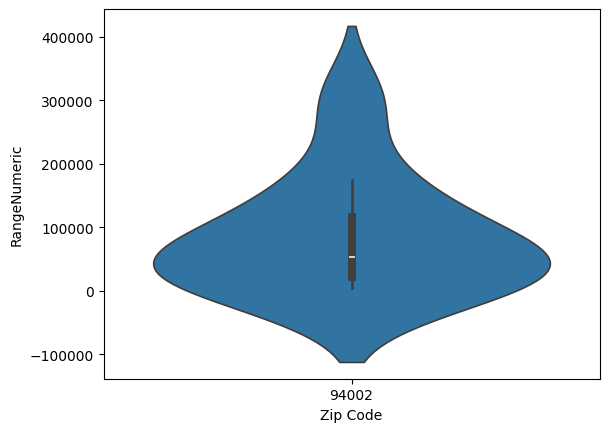

In [ ]:
# Create violin plot
sns.violinplot(x='Zip Code', y="RangeNumeric", data=z_94002_long)
# Yes!! Finally

##03.6 - Map range values to numeric values for all zip codes

In [ ]:
# Pull cleaned income df
income_counts_link = "https://raw.githubusercontent.com/veronicaj8345/DataJam/main/income_SMC_counts.csv"
income_SMC_counts = pd.read_csv(income_counts_link)
income_SMC_counts.head()

,Zip Code,Total Households,$0 - $10k,$10k - $15k,$15k - $25k,$25k - $35k,$35k - $50k,$50k - $75k,$75k - $100k,$100k - $150k,$150k - $200k,$200k+,Median Income,Mean Income
0,94002,10854,271,379,358,303,325,781,575,1443,1204,5209,184929,238074
1,94005,1902,62,0,30,0,273,207,148,306,176,696,137583,252170
2,94010,16070,449,128,369,401,723,1237,1189,2024,1976,7568,186198,297111
3,94014,14014,518,462,728,700,1065,1345,1597,2662,2298,2648,111795,134129
4,94015,20476,716,429,798,839,1126,2109,2600,4136,2743,4975,117289,147777


In [ ]:
# make new df without the median and such

income_SMC_counts_1 = income_SMC_counts.drop(columns=['Total Households', 'Median Income', 'Mean Income'])
income_SMC_counts_1.head()

,Zip Code,$0 - $10k,$10k - $15k,$15k - $25k,$25k - $35k,$35k - $50k,$50k - $75k,$75k - $100k,$100k - $150k,$150k - $200k,$200k+
0,94002,271,379,358,303,325,781,575,1443,1204,5209
1,94005,62,0,30,0,273,207,148,306,176,696
2,94010,449,128,369,401,723,1237,1189,2024,1976,7568
3,94014,518,462,728,700,1065,1345,1597,2662,2298,2648
4,94015,716,429,798,839,1126,2109,2600,4136,2743,4975


In [ ]:
# Transpose the DataFrame to convert it to long format
income_SMC_counts_1_long = income_SMC_counts_1.melt(id_vars=['Zip Code'], var_name='Income Range', value_name='Count')
income_SMC_counts_1_long.head()

,Zip Code,Income Range,Count
0,94002,$0 - $10k,271
1,94005,$0 - $10k,62
2,94010,$0 - $10k,449
3,94014,$0 - $10k,518
4,94015,$0 - $10k,716


In [ ]:
# Make map for Income Range numeric values and map to df
income_range_map = {'$0 - $10k': 5000,
                    '$10k - $15k':12500,
                    '$15k - $25k':20000,
                    '$25k - $35k':30000,
                    '$35k - $50k':42500,
                    '$50k - $75k':62500,
                    '$75k - $100k':87500,
                    '$100k - $150k':125000,
                    '$150k - $200k':175000,
                    '$200k+':300000}
income_SMC_counts_1_long['RangeNumeric'] = income_SMC_counts_1_long['Income Range'].map(income_range_map)



In [ ]:
income_SMC_counts_1_long.head(10)

,Zip Code,Income Range,Count,RangeNumeric
0,94002,$0 - $10k,271,5000
1,94005,$0 - $10k,62,5000
2,94010,$0 - $10k,449,5000
3,94014,$0 - $10k,518,5000
4,94015,$0 - $10k,716,5000
5,94018,$0 - $10k,0,5000
6,94019,$0 - $10k,149,5000
7,94020,$0 - $10k,32,5000
8,94021,$0 - $10k,0,5000
9,94025,$0 - $10k,301,5000


<Axes: xlabel='Zip Code', ylabel='RangeNumeric'>

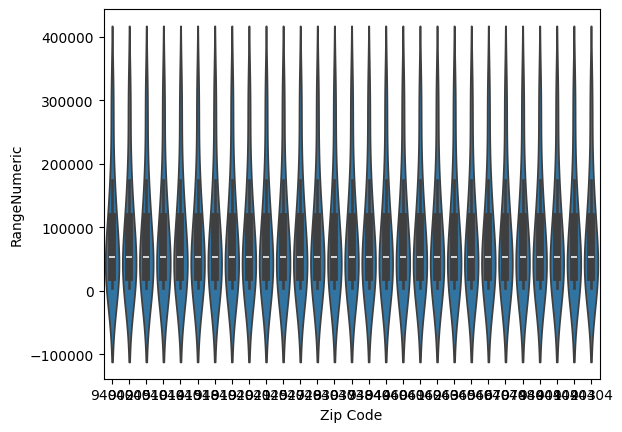

In [ ]:
# Create violin plot
sns.violinplot(x='Zip Code', y="RangeNumeric", data=income_SMC_counts_1_long)

In [ ]:
income_SMC_counts_1_long['Zip Code'] = income_SMC_counts_1_long['Zip Code'].astype('object')

In [ ]:
income_SMC_counts_1_long.dtypes

Zip Code        object
Income Range    object
Count            int64
RangeNumeric     int64
dtype: object

<Axes: xlabel='Zip Code', ylabel='RangeNumeric'>

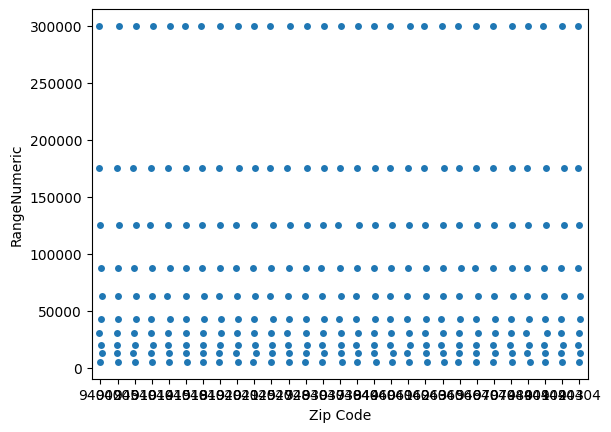

In [ ]:
# Create scatter plot
sns.stripplot(x='Zip Code', y="RangeNumeric", data=income_SMC_counts_1_long)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

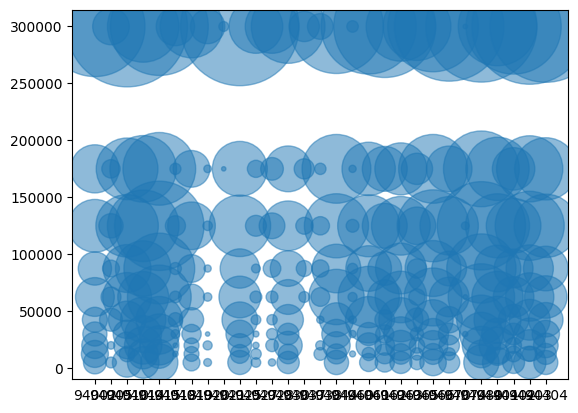

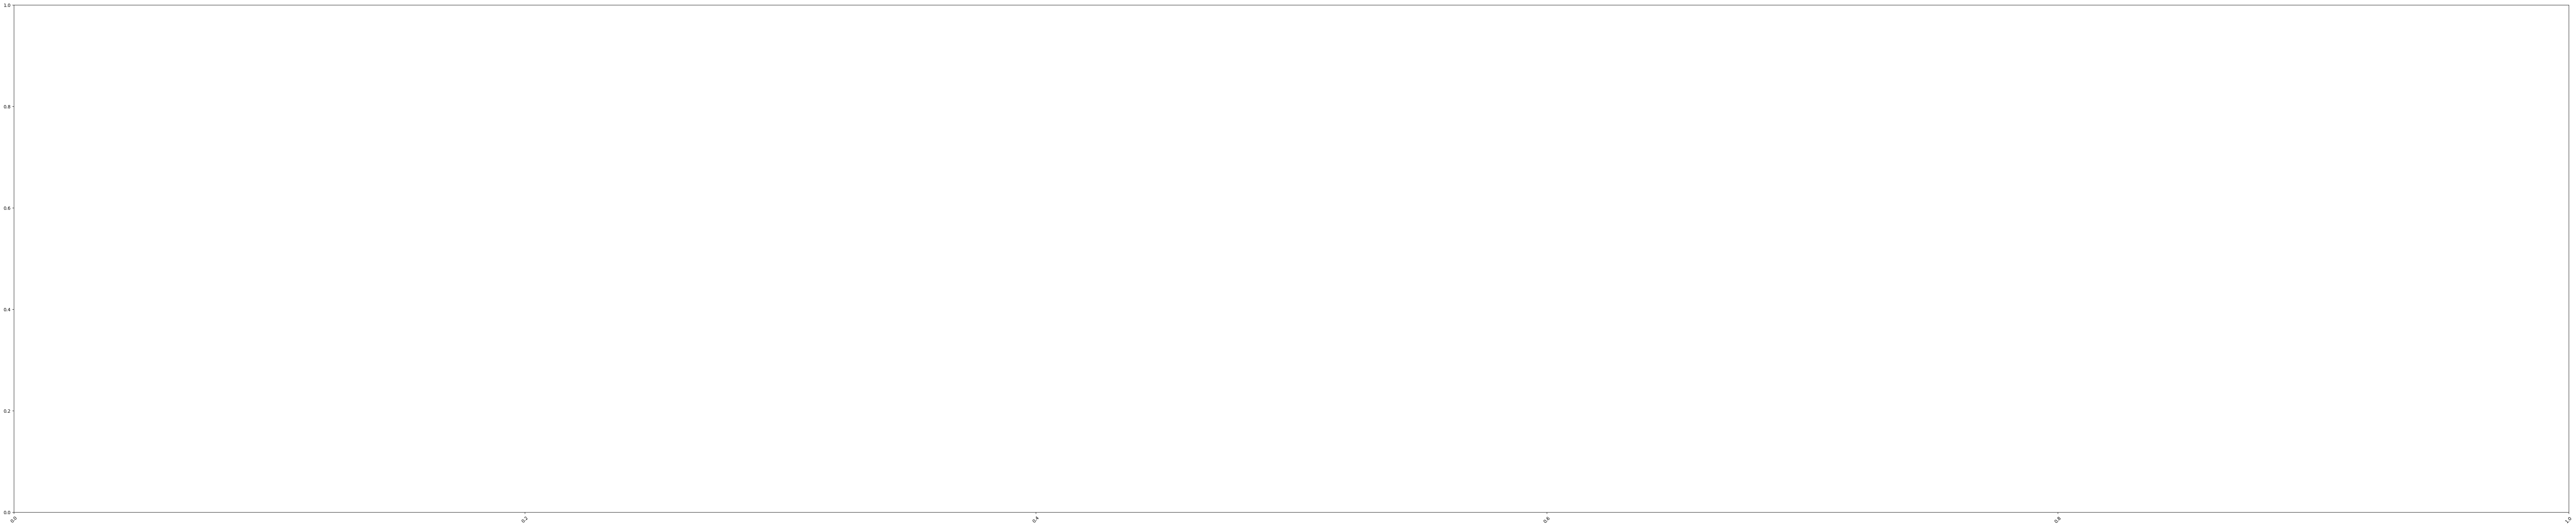

In [ ]:
plt.scatter(x='Zip Code', y="RangeNumeric", data=income_SMC_counts_1_long, s='Count', alpha=0.5)
plt.figure(figsize=(100, 20))
plt.xticks(rotation=45)

In [ ]:
# Let's try and subset the data to see better
subset1 = income_SMC_counts_1_long.sort_values(by=['Zip Code', 'RangeNumeric'], ascending=True).head(50)
subset1.head()

,Zip Code,Income Range,Count,RangeNumeric
0,94002,$0 - $10k,271,5000
29,94002,$10k - $15k,379,12500
58,94002,$15k - $25k,358,20000
87,94002,$25k - $35k,303,30000
116,94002,$35k - $50k,325,42500


([0, 1, 2, 3, 4],
 [Text(0, 0, '94002'),
  Text(1, 0, '94005'),
  Text(2, 0, '94010'),
  Text(3, 0, '94014'),
  Text(4, 0, '94015')])

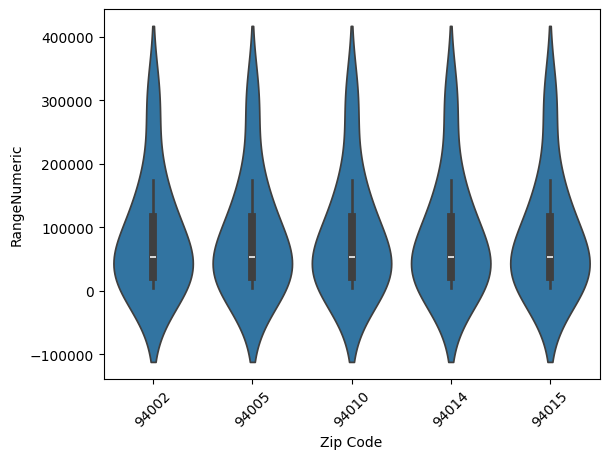

In [ ]:
# Create violin plot
sns.violinplot(data=subset1, x='Zip Code', y='RangeNumeric')
plt.xticks(rotation=45)

## 03.7 - Ratio of under 100k to over 100k

In [ ]:
# Pull cleaned income df
income_counts_link = "https://raw.githubusercontent.com/veronicaj8345/DataJam/main/income_SMC_counts.csv"
income_SMC_counts = pd.read_csv(income_counts_link)
income_SMC_counts.head()

# 02 - GeoPandas

## 02.1 - Instructions for other group members

In [ ]:
# Pull zip code map data from my github
# Source: https://data.smcgov.org/Government/Zip-Codes-Areas/xq2v-znpu/about_data
# Map: https://data.smcgov.org/Government/Zip-Code-Areas-Map/39f7-4fdy
map = gpd.read_file("https://raw.githubusercontent.com/veronicaj8345/DataJam/main/Zip%20Codes%20-%20Areas_20240309.geojson")
map.head()

,zip_code,pop_sqmi,sqmi,population,po_name,geometry
0,94002,4662.61,5.75,26810,Belmont,"MULTIPOLYGON (((-122.26821 37.52822, -122.2681..."
1,94005,896.84,5.06,4538,Brisbane,"MULTIPOLYGON (((-122.39114 37.69319, -122.3909..."
2,94010,3179.92,12.9,41021,Burlingame,"MULTIPOLYGON (((-122.33304 37.58786, -122.3332..."
3,94014,8203.21,5.92,48563,Daly City,"MULTIPOLYGON (((-122.40826 37.70235, -122.4083..."
4,94015,11207.71,5.58,62539,Daly City,"MULTIPOLYGON (((-122.46628 37.66991, -122.4662..."


<Axes: >

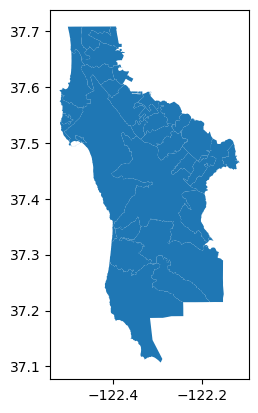

In [ ]:
# View map of zip code boundaires. Very simple with geopandas
map.plot()

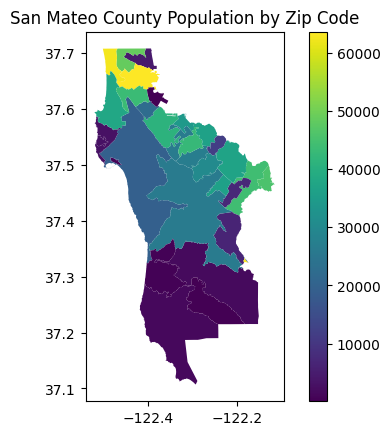

In [ ]:
# What else can we do with geopandas?
# Let's try color coding based on another column. Try population to start

# First let's convert the population column from object form to integer
map['population'] = map['population'].astype(int)

# Now plot and add labels
map.plot(column = 'population', legend=True)
plt.title('San Mateo County Population by Zip Code')
plt.show()

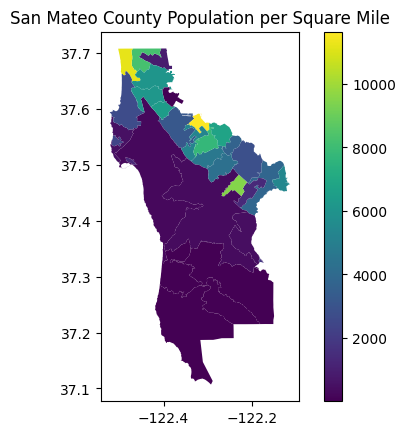

In [ ]:
# What about population density?

# Convert population per square mile column to float form (allows for decimal points)
map['pop_sqmi'] = map['pop_sqmi'].astype(float)
# Plot
map.plot(column = 'pop_sqmi', legend=True)
plt.title("San Mateo County Population per Square Mile")
plt.show()

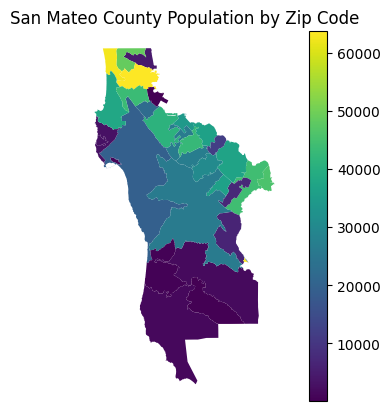

In [ ]:
# Let's customize our plots

# Remove axis ticks on the sides
ax = map.plot(column = 'population', legend=True)
ax.set_axis_off()

plt.title('San Mateo County Population by Zip Code')
plt.show()

First draft stuff below this line. Can be informative but not necessary

<Axes: >

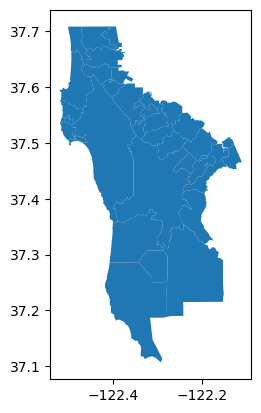

In [ ]:
# Pull file of zip code boundaries with geometry data
# Download from my github or the source and upload the whole zip file
# Sorry I can't figure out how to get it to read the raw link directly
# Github link: https://github.com/veronicaj8345/DataJam/blob/main/SMC_zipcodes_shapefile.zip
# Source: https://geodata.lib.berkeley.edu/catalog/stanford-gm175wm1954 (change zip file namein code)
map_SMC = gpd.read_file('SMC_zipcodes_shapefile.zip')
map_SMC.plot()

In [ ]:
# Actually I may have found a better source of data
# Source: https://data.smcgov.org/Government/Zip-Codes-Areas/xq2v-znpu/about_data
# Map: https://data.smcgov.org/Government/Zip-Code-Areas-Map/39f7-4fdy
# map = gpd.read_file('Zip_Codes_-_Areas_20240309.csv')
# map

# Hmm. I remember this one now. Let's see if I can reset the active geometry
# Let's try exporting it as a shapefile
# map = gpd.read_file('SMC_zipcodes_shapefile.zip')
# map.plot()
# That worked but it cut out all the population data

# What about as a geojson?
map = gpd.read_file('Zip Codes - Areas_20240309.geojson')
map.head()
# Phew. That worked. Let's clean this up for the other kids

,zip_code,pop_sqmi,sqmi,population,po_name,geometry
0,94002,4662.61,5.75,26810,Belmont,"MULTIPOLYGON (((-122.26821 37.52822, -122.2681..."
1,94005,896.84,5.06,4538,Brisbane,"MULTIPOLYGON (((-122.39114 37.69319, -122.3909..."
2,94010,3179.92,12.9,41021,Burlingame,"MULTIPOLYGON (((-122.33304 37.58786, -122.3332..."
3,94014,8203.21,5.92,48563,Daly City,"MULTIPOLYGON (((-122.40826 37.70235, -122.4083..."
4,94015,11207.71,5.58,62539,Daly City,"MULTIPOLYGON (((-122.46628 37.66991, -122.4662..."


## 02.2 - Veronica scratchpaper

In [ ]:
# Import shape file of SMC city boundaries
# cities_url = "https://raw.githubusercontent.com/veronicaj8345/DataJam/main/CITY.shp"
# cities_SMC = gpd.read_file(cities_url)
# Not sure why I can't pull from GitHub raw link. Gonna try to upload it directly

cities_SMC = gpd.read_file('Boundaries-shp.zip')
cities_SMC
# may have to upload entire .zip file for it to read right. Got it now

,NAME,ABBR,COMMENTS,ID,UNICORPORA,GlobalID,geometry
0,Pescadero,SMC,None,1,-1.0,cef47c95-54a9-497a-949a-64556c257137,"POLYGON ((-122.41274 37.26725, -122.41266 37.2..."
1,Loma Mar,SMC,None,2,-1.0,09af0046-8870-47be-a1f7-555fecf40e0e,"POLYGON ((-122.32874 37.26632, -122.32877 37.2..."
2,Moss Beach,SMC,None,4,-1.0,13d58cf0-e578-4acb-9fc8-2309789f043f,"POLYGON ((-122.51943 37.53318, -122.51902 37.5..."
3,Montara,SMC,None,5,-1.0,7e2dc125-7a17-41bf-b07d-662d46a6f0e8,"POLYGON ((-122.51498 37.54774, -122.51498 37.5..."
4,Princenton,SMC,None,6,-1.0,decd8a9a-4a0b-4e94-a49a-144ca49f92fe,"POLYGON ((-122.49280 37.50169, -122.49296 37.5..."
...,...,...,...,...,...,...,...
60,Half Moon Bay,HMB,D,127,0.0,34b7df3b-cc04-4c8f-acbd-ccf024b79983,"POLYGON ((-122.46652 37.49834, -122.46618 37.4..."
61,Redwood City,RWC,None,141,NaN,3ce9560f-f903-4b01-8085-ddd355f1bf8c,"POLYGON ((-122.22030 37.54294, -122.22039 37.5..."
62,Redwood City,RWC,None,142,NaN,20d086f8-8d16-4cfa-b122-17e1d3d221b9,"POLYGON ((-122.21405 37.54118, -122.21414 37.5..."
63,Menlo Park,MP,None,161,NaN,cd06ea42-4686-435e-93d1-8c6270796bec,"POLYGON ((-122.12069 37.47676, -122.12069 37.4..."


<Axes: >

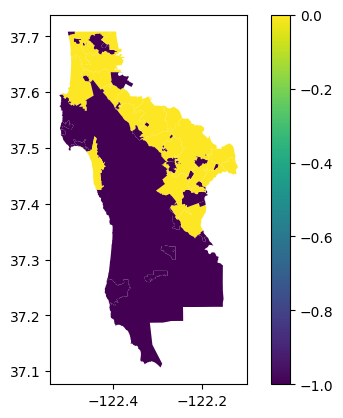

In [ ]:
# See unincorportated areas. 0 = incorporated -1 = unincoprorated I think
cities_SMC.plot(column='UNICORPORA', legend=True)
# This file is just the shapes. Can I merge it with a df of population to make a map of that?


In [ ]:
# Can I get a geodf of zip code boundaries?
# Source: https://data.smcgov.org/Government/Zip-Code-Areas-Map/39f7-4fdy
zipcodes_SMC = gpd.read_file('Zip_Codes_-_Areas_20240304.csv')
zipcodes_SMC.head()

# set active geometry to 'the_geom'
# gdf = zipcodes_SMC.set_geometry('the_geom')
# gdf.head()
# are they not in the right format?


,the_geom,ZIP_CODE,PO_NAME,POPULATION,POP_SQMI,SQMI,geometry
0,MULTIPOLYGON (((-122.2682088446232 37.52821501...,94002,Belmont,26810,4662.61,5.75,None
1,MULTIPOLYGON (((-122.39113840779514 37.6931914...,94005,Brisbane,4538,896.84,5.06,None
2,MULTIPOLYGON (((-122.3330402279353 37.58785711...,94010,Burlingame,41021,3179.92,12.9,None
3,MULTIPOLYGON (((-122.40826380425433 37.7023470...,94014,Daly City,48563,8203.21,5.92,None
4,MULTIPOLYGON (((-122.46628479870415 37.6699110...,94015,Daly City,62539,11207.71,5.58,None


In [ ]:
# let's try the zipcode thing again from another source
# https://geodata.lib.berkeley.edu/catalog/stanford-gm175wm1954
zipcodes_SMC = gpd.read_file('stanford-gm175wm1954-shapefile.zip')
zipcodes_SMC.head()

# join with a file of population data
# Source: https://worldpopulationreview.com/us-counties/ca/san-mateo-county/zips
pop = pd.read_csv('SMC_Population.csv')
pop.head()

# check datatypes of zipcode column before merging
# zipcodes_SMC = object
# pop = int64
pop.dtypes

# Change zipcode column to int
zipcodes_SMC['zipcode'] = zipcodes_SMC['zipcode'].astype(int)
zipcodes_SMC.dtypes

# merge
# cars_SMC = pd.merge(cars_CA, list_SMC, on='Zip Code', how='inner')
zipcodes_pop = pd.merge(zipcodes_SMC, pop, on='zipcode', how='inner')
zipcodes_pop.head()

zipcode          int64
zip_city        object
geometry_a     float64
geometry_l     float64
geometry      geometry
Population       int64
City            object
Source          object
dtype: object

<Axes: >

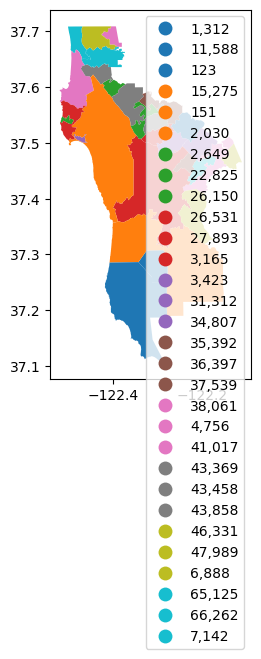

In [ ]:
# Now that I have zip code boundaries and population I can map it out
zipcodes_pop.plot(column='Population', legend=True)
# Hmm. It seems to have read the populations and put them in order like it was alphabetizing. Not helpful
# How can I make it treat it as a range of numbers?

<ipython-input-19-8e7cd43b48ac>:3: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


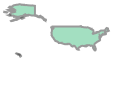

In [ ]:
# From tutorial https://cybergisxhub.cigi.illinois.edu/notebook/spatial-data-exploration-and-visualization-on-google-colab/
# Grab low resolution world file
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
world = world.set_index("iso_a3")

world.loc["USA", 'geometry']


In [ ]:
# Can I make a map that represents areas with a higher proportion of EVs?


# 01 - Graphing SMC

In [ ]:
# Pull dataset filtered to San Mateo County from GitHub
SMC_url = 'https://raw.githubusercontent.com/veronicaj8345/DataJam/main/cars_SMC.csv'
cars_SMC = pd.read_csv(SMC_url)
cars_SMC = cars_SMC.drop(columns = ["Unnamed: 0"])
cars_SMC

,Date,Zip Code,Model Year,Fuel,Make,Duty,Vehicles,City
0,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Heavy,2,Belmont
1,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Light,65,Belmont
2,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Unk,25,Belmont
3,12/31/2022,94002,2008,Gasoline,FORD,Light,33,Belmont
4,12/31/2022,94002,2008,Gasoline,CHEVROLET,Light,11,Belmont
...,...,...,...,...,...,...,...,...
19451,12/31/2022,94405,2015,Gasoline,OTHER/UNK,Light,2,San Mateo
19452,12/31/2022,94407,2011,Gasoline,OTHER/UNK,Light,1,San Mateo
19453,12/31/2022,94407,2014,Gasoline,OTHER/UNK,Light,1,San Mateo
19454,12/31/2022,94407,<2009,Gasoline,OTHER/UNK,Light,3,San Mateo


<ipython-input-36-2da80ae0ab58>:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  cars_SMC.groupby(['Fuel']).sum().plot(kind='pie', y='Vehicles', autopct='%1.0f%%')


<Axes: ylabel='Vehicles'>

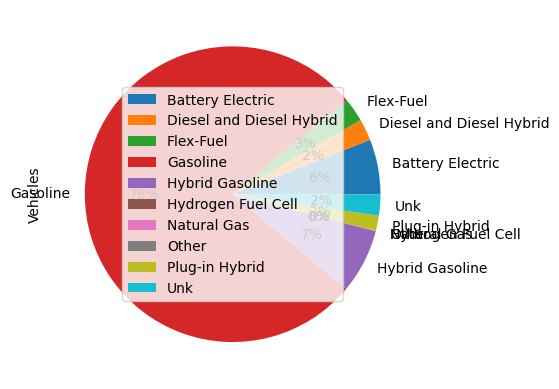

In [ ]:
# Make pie chart of fuel and vehicle count with percentages
cars_SMC.groupby(['Fuel']).sum().plot(kind='pie', y='Vehicles', autopct='%1.0f%%')
# That works but it's ugly

## 01.1 - Group by Fuel





In [ ]:
# Look at count of fuel type across entire county

# Sum 'Vehicles' and group by 'Fuel'
fuel_SMC_data = cars_SMC.groupby(["Fuel"]).Vehicles.sum()
# Convert series to dataframe
fuel_SMC = pd.DataFrame(data=fuel_SMC_data).reset_index()
fuel_SMC.columns = ['Fuel', 'Count']
# Sort descending
fuel_SMC.sort_values(by=["Count"], ascending = False)

,Fuel,Count
3,Gasoline,614394
4,Hybrid Gasoline,55283
0,Battery Electric,47251
2,Flex-Fuel,20531
1,Diesel and Diesel Hybrid,18563
9,Unk,18328
8,Plug-in Hybrid,12933
5,Hydrogen Fuel Cell,312
6,Natural Gas,241
7,Other,58


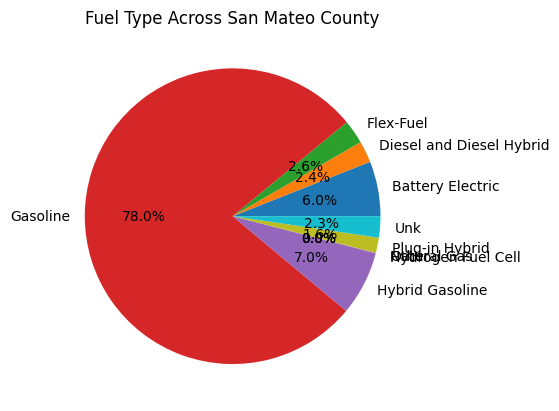

In [ ]:
# Graphing fuel_SMC with Seaborn to avoid dealing with a big legend

plt.pie(fuel_SMC['Count'], labels=fuel_SMC['Fuel'], autopct='%1.1f%%')
plt.title('Fuel Type Across San Mateo County')
plt.show()

# That works but the graph is messy. Let's see if we can simplify

## 01.2 - Group by Fuel categories

In [ ]:
# Group together fuel types into different categories
# First up: Traditional VS Alternative Fuel

# Make a directory where the keys are the Fuel types and the values are Traditional, Alternative or Other
fuel_group_1 = {'Gasoline':'Traditional'
                   ,'Hybrid Gasoline':'Alternative'
                   ,'Battery Electric':'Alternative'
                   ,'Flex-Fuel':'Alternative'
                   ,'Diesel and Diesel Hybrid':'Traditional'
                   ,'Unk':'Other'
                   ,'Plug-in Hybrid':'Alternative'
                   ,'Hydrogen Fuel Cell':'Alternative'
                   ,'Natural Gas':'Alternative'
                   ,'Other':'Other'}
# Map variable and assign output to new variable. Add up by Group and assign to new dataframe
fuel_SMC_1_data = fuel_SMC.assign(Group = fuel_SMC.Fuel.map(fuel_group_1))
fuel_SMC_1_data
# Do this next part if you want a tidyier dataframe of just trad/alt/other. Keep as is for stacked bar plot
# fuel_SMC_1_data = fuel_SMC_1_data.groupby('Group').Count.sum()

# fuel_SMC_1 = pd.DataFrame(data=fuel_SMC_1_data).reset_index()
# fuel_SMC_1.columns = ["Group", "Count"]
# fuel_SMC_1

NameError: name 'fuel_SMC' is not defined

{'Gasoline':
                   ,'Hybrid Gasoline':
                   ,'Battery Electric':
                   ,'Flex-Fuel':
                   ,'Diesel and Diesel Hybrid':
                   ,'Unk':
                   ,'Plug-in Hybrid':
                   ,'Hydrogen Fuel Cell':
                   ,'Natural Gas':
                   ,'Other':}

<Axes: xlabel='Group', ylabel='Count'>

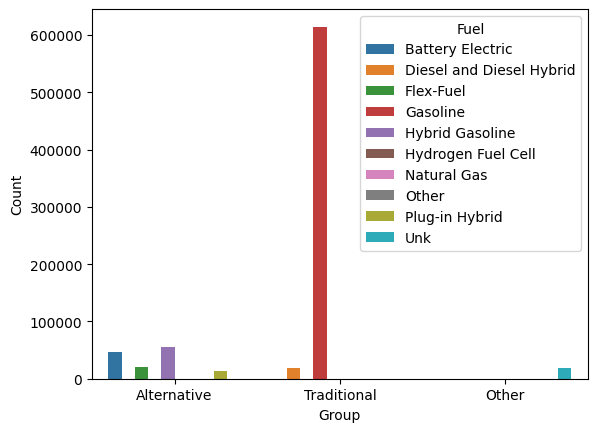

In [ ]:
# Barplot
sns.barplot(x = "Group",
            y = "Count",
            hue = "Fuel",
            data = fuel_SMC_1_data)
# that's a start, but can I stack the bars?

Text(0, 0.5, 'Count')

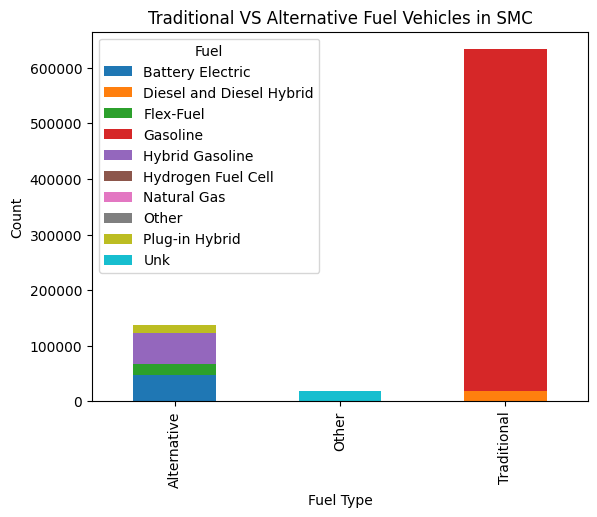

In [ ]:
# Stacked bar chart attempt - pivot table method
p1 = fuel_SMC_1_data.pivot(index = ['Group'], columns = 'Fuel', values = 'Count')
p1.plot(kind='bar', stacked=True)
# Pivoting the data worked!! The pivot table is messy and full of NaNs but whatever
# Add title and such
plt.title ('Traditional VS Alternative Fuel Vehicles in SMC')
plt.xlabel ('Fuel Type')
plt.ylabel ('Count')

In [ ]:
# Maybe I can jump ahead a little bit and apply this pivot table method to break down type by city
# Make pivot table
p2 = cars_SMC.pivot(index = 'City',
                    columns = 'Fuel',
                    values = 'Vehicles')
p2
# Hmm. That didn't work. Let's try trimming down the dataset to just what I need

ValueError: Index contains duplicate entries, cannot reshape

In [ ]:
# Neaten up the cars_SMC dataset to just what I need for this chart
fuel_city = cars_SMC.groupby(['City', 'Zip Code', 'Fuel']).sum('Vehicles')
# Convert series to dataframe
#fuel_SMC = pd.DataFrame(data=fuel_SMC_data).reset_index()
fuel_city = pd.DataFrame(data = fuel_city)
fuel_city

Vehicles
City                Zip Code Fuel                              
Airport Mail Center 94128    Battery Electric                 2
                             Diesel and Diesel Hybrid        38
                             Flex-Fuel                      154
                             Gasoline                       417
                             Hybrid Gasoline                 15
...                                                         ...
Woodside            94062    Hydrogen Fuel Cell               8
                             Natural Gas                      8
                             Other                            1
                             Plug-in Hybrid                 565
                             Unk                           1215

[406 rows x 1 columns]

In [ ]:
fuel_city['Zip Code'].plot(kind='bar', stacked=True)

KeyError: 'Zip Code'

Text(0, 0.5, 'Pies Consumed')

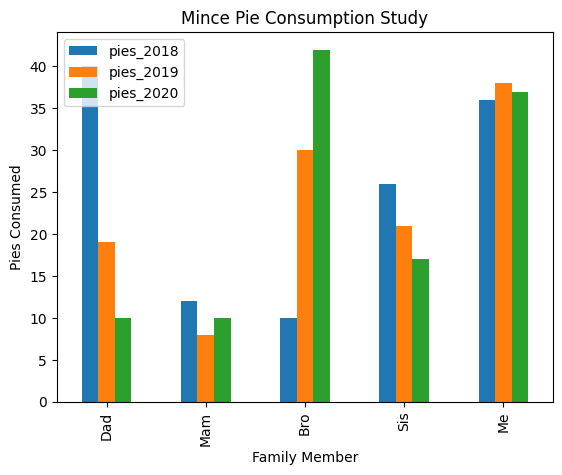

In [ ]:
# Pivot data example. Not related to this
plotdata = pd.DataFrame({
    "pies_2018":[40, 12, 10, 26, 36],
    "pies_2019":[19, 8, 30, 21, 38],
    "pies_2020":[10, 10, 42, 17, 37]
    },
    index=["Dad", "Mam", "Bro", "Sis", "Me"]
)
plotdata.plot(kind="bar")
plt.title("Mince Pie Consumption Study")
plt.xlabel("Family Member")
plt.ylabel("Pies Consumed")

In [ ]:
# City x Fuel type pivot table

# First make tidy df before we pivot of just City, Fuel and Vehicle count
zap = cars_SMC.groupby(['City', 'Fuel']).sum('Vehicles').reset_index()
# Not sure why the Zip Code column is still hanging around. It added them all up so it's not useful
zap.drop('Zip Code', axis=1, inplace=True)

# Then pivot df to show Fuel types by City. Replace NaNs with 0s
zap_p = zap.pivot_table(index='City', columns='Fuel', values='Vehicles', aggfunc='sum', fill_value=0)
zap_p
# zap_p.plot(kind='bar', stacked=True)

# Sort by smallest to largest for sum of both columns and rows
# zap_p1 = zap_p.sort_values(by=['City'], ascending=[0])


Fuel,Battery Electric,Diesel and Diesel Hybrid,Flex-Fuel,Gasoline,Hybrid Gasoline,Hydrogen Fuel Cell,Natural Gas,Other,Plug-in Hybrid,Unk
City,,,,,,,,,,
Airport Mail Center,2,38,154,417,15,0,0,0,4,8
Atherton,849,124,125,4505,352,2,1,1,177,233
Belmont,1568,377,479,16730,1723,13,0,0,440,459
Brisbane,213,277,197,3269,323,2,0,0,74,109
Burlingame,2767,1048,1041,27232,2646,13,21,9,766,905
Colma,688,333,710,26754,2340,15,4,0,281,457
Daly City,1792,736,1519,61930,6302,41,39,1,695,953
El Granada,103,152,118,2388,218,0,0,0,62,100
Emerald Hills,1958,809,573,17391,1562,8,8,1,565,1215


In [ ]:
# Going to try to cheat and just use the count for gasoline instead of adding them all together
# Using stuff from the 2nd Python workshop on 2/28
zap_p.groupby

417      2
17391    2
14162    1
66182    1
86372    1
157      1
19984    1
27849    1
72256    1
4222     1
1165     1
3        1
24586    1
2053     1
1813     1
32240    1
4505     1
117      1
1059     1
26857    1
10966    1
20933    1
2388     1
61930    1
26754    1
27232    1
3269     1
16730    1
22994    1
Name: Gasoline, dtype: int64

In [ ]:
cars_SMC

,Date,Zip Code,Model Year,Fuel,Make,Duty,Vehicles,City
0,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Heavy,2,Belmont
1,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Light,65,Belmont
2,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Unk,25,Belmont
3,12/31/2022,94002,2008,Gasoline,FORD,Light,33,Belmont
4,12/31/2022,94002,2008,Gasoline,CHEVROLET,Light,11,Belmont
...,...,...,...,...,...,...,...,...
19451,12/31/2022,94405,2015,Gasoline,OTHER/UNK,Light,2,San Mateo
19452,12/31/2022,94407,2011,Gasoline,OTHER/UNK,Light,1,San Mateo
19453,12/31/2022,94407,2014,Gasoline,OTHER/UNK,Light,1,San Mateo
19454,12/31/2022,94407,<2009,Gasoline,OTHER/UNK,Light,3,San Mateo


In [ ]:
# Zip Code x Fuel type pivot table

# First make tidy df before we pivot of just Zip, Fuel and Vehicle count
zip = cars_SMC.groupby(['Zip Code', 'Fuel']).sum('Vehicles').reset_index()

# Pivot
zip_p = zip.pivot_table(index='Zip Code', columns='Fuel', values='Vehicles', aggfunc='sum', fill_value=0)
zip_p

Fuel,Battery Electric,Diesel and Diesel Hybrid,Flex-Fuel,Gasoline,Hybrid Gasoline,Hydrogen Fuel Cell,Natural Gas,Other,Plug-in Hybrid,Unk
Zip Code,,,,,,,,,,
94002,1568,374,479,16715,1721,13,0,0,440,459
94003,0,3,0,15,2,0,0,0,0,0
94005,213,277,197,3269,323,2,0,0,74,109
94010,5516,2022,2044,53714,5246,26,42,18,1524,1750
94011,9,37,19,375,23,0,0,0,4,30
94014,1376,666,1420,53508,4680,30,8,0,562,914
94015,1102,397,791,34827,3934,25,35,1,414,480
94016,0,1,1,56,3,0,0,0,0,1
94017,2,5,17,293,25,1,0,0,0,15


In [ ]:
# Zip Code x Fuel type pivot table (include city name)

# First make tidy df before we pivot of just Zip, Fuel and Vehicle count
zip1 = cars_SMC.groupby(['Zip Code', 'City', 'Fuel']).sum('Vehicles').reset_index()
zip1

# Pivot
zip1_p = zip1.pivot_table(index=['City', 'Zip Code'], columns='Fuel', values='Vehicles', aggfunc='sum', fill_value=0)
zip1_p

Fuel                          Battery Electric  Diesel and Diesel Hybrid  \
City                Zip Code                                               
Airport Mail Center 94128                    2                        38   
Atherton            94027                  849                       124   
Belmont             94002                 1568                       374   
                    94003                    0                         3   
Brisbane            94005                  213                       277   
Burlingame          94010                 2758                      1011   
                    94011                    9                        37   
Colma               94014                  688                       333   
Daly City           94014                  688                       333   
                    94015                 1102                       397   
                    94016                    0                         1   
                    94017                    2                         5   
El Granada          94018                  103                       152   
Emerald Hills       94062                 1958                       809   
Foster City         94404                 1856                       294   
Half Moon Bay       94019                  531                       772   
Hillsborough        94010                 2758                      1011   
La Honda            94020                   46                       137   
Loma Mar            94021                    3                        14   
Menlo Park          94025                 2934                       979   
                    94026                   17                        22   
                    94027                  849                       124   
                    94028                  780                       194   
Millbrae            94030                 1019                       272   
Montara             94037                  128                       122   
Moss Beach          94038                  100                       110   
Pacifica            94044                 1030                       716   
                    94045                    0                         0   
Palo Alto           94307                    0                         0   
                    94308                    0                         0   
Pescadero           94060                   16                       148   
Portola Valley      94028                  780                       194   
Redwood City        94061                 1165                       538   
                    94062                 1958                       809   
                    94063                  727                      1039   
                    94064                    2                        41   
                    94065                  849                       136   
San Bruno           94066                  987                       553   
                    94067                    0                         1   
San Carlos          94070                 2057                      1247   
                    94071                    0                         0   
San Francisco       94128                    2                        38   
San Gregorio        94074                    4                        52   
San Mateo           94401                  670                       474   
                    94402                 1425                       427   
                    94403                 1708                       520   
                    94404                 1856                       294   
                    94405                    0                         0   
                    94407                    0                         0   
                    94409                    0                         0   
South San Francisco 94080                 6158  

In [ ]:
# Let's see if I can assign trad/alt/other to fuel types like I did before to the zip1 df

# Make a directory where the keys are the Fuel types and the values are Traditional, Alternative or Other
fuel_group_1 = {'Gasoline':'Traditional'
                   ,'Hybrid Gasoline':'Alternative'
                   ,'Battery Electric':'Alternative'
                   ,'Flex-Fuel':'Alternative'
                   ,'Diesel and Diesel Hybrid':'Traditional'
                   ,'Unk':'Other'
                   ,'Plug-in Hybrid':'Alternative'
                   ,'Hydrogen Fuel Cell':'Alternative'
                   ,'Natural Gas':'Alternative'
                   ,'Other':'Other'}

# Map variable and assign output to new variable. Add up by Group and assign to new dataframe
zip2 = zip1.assign(Group = zip1.Fuel.map(fuel_group_1))
zip2

# Can I reflect this in the pivot table
zip2_p = zip2.pivot_table(index=['City', 'Zip Code'],
                          columns=['Group', 'Fuel'],
                          values='Vehicles',
                          aggfunc='sum',
                          fill_value=0)
zip2_p

Group                             Alternative                            \
Fuel                         Battery Electric Flex-Fuel Hybrid Gasoline   
City                Zip Code                                              
Airport Mail Center 94128                   2       154              15   
Atherton            94027                 849       125             352   
Belmont             94002                1568       479            1721   
                    94003                   0         0               2   
Brisbane            94005                 213       197             323   
Burlingame          94010                2758      1022            2623   
                    94011                   9        19              23   
Colma               94014                 688       710            2340   
Daly City           94014                 688       710            2340   
                    94015                1102       791            3934   
                    94016                   0         1               3   
                    94017                   2        17              25   
El Granada          94018                 103       118             218   
Emerald Hills       94062                1958       573            1562   
Foster City         94404                1856       447            2631   
Half Moon Bay       94019                 531       528             831   
Hillsborough        94010                2758      1022            2623   
La Honda            94020                  46        41              84   
Loma Mar            94021                   3         4              14   
Menlo Park          94025                2934       773            2360   
                    94026                  17        53              33   
                    94027                 849       125             352   
                    94028                 780       116             577   
Millbrae            94030                1019       381            1461   
Montara             94037                 128        82             178   
Moss Beach          94038                 100        73             152   
Pacifica            94044                1030      1061            2212   
                    94045                   0         0               0   
Palo Alto           94307                   0         0               0   
                    94308                   0         1               0   
Pescadero           94060                  16        77              62   
Portola Valley      94028                 780       116             577   
Redwood City        94061                1165       738            1705   
                    94062                1958       573            1562   
                    94063                 727      1297            1455   
                    94064                   2        36              23   
                    94065                 849       138             688   
San Bruno           94066                 987       968            2427   
                    94067                   0         0               0   
San Carlos          94070                2057       795            1887   
                    94071                   0         0               0   
San Francisco       94128                   2       154              15   
San Gregorio        94074                   4        15              13   
San Mateo           94401                 670       766            1666   
                    94402                1425       477            1550   
                    94403                1708       750            2499   
                    94404                1856       447            2631   
                    94405                   0         0               1   
                    94407                   0         0               0   
                    94409                   0         0               0   
South San Francisco 94080

<Axes: xlabel='City,Zip Code'>

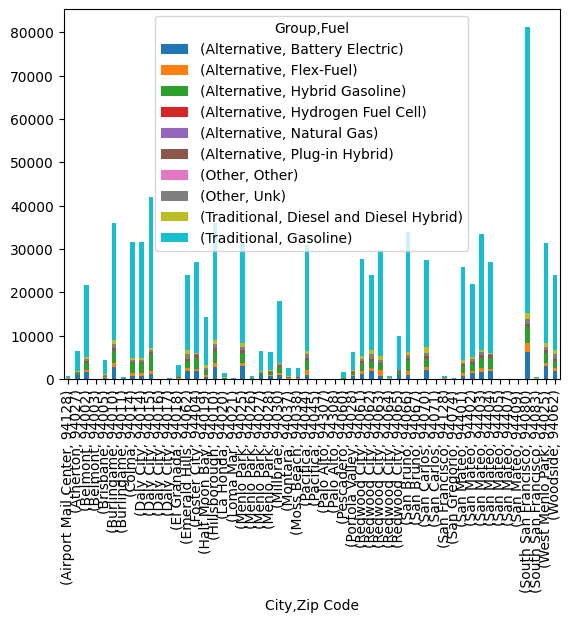

In [ ]:
# Let's make a stacked bar chart from the zip2_p df
# df.pivot_table(index='battle_type', columns='attacker_outcome', aggfunc='size').plot.barh(stacked=True)
zip2_p.plot(kind="bar", stacked=True)

## 01.3 - Asking ChatGPT for help

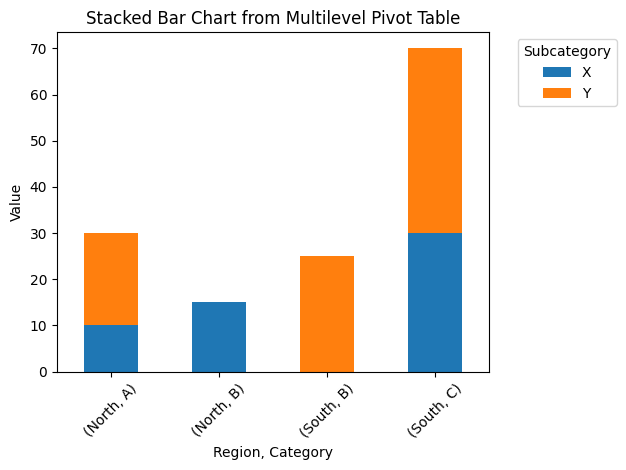

In [ ]:

# Create a sample DataFrame
data = {
    'Region': ['North', 'North', 'North', 'South', 'South', 'South'],
    'Category': ['A', 'A', 'B', 'B', 'C', 'C'],
    'Subcategory': ['X', 'Y', 'X', 'Y', 'X', 'Y'],
    'Value': [10, 20, 15, 25, 30, 40]
}

df = pd.DataFrame(data)

# Create a pivot table with multiple levels
pivot_table = df.pivot_table(index=['Region', 'Category'], columns='Subcategory', values='Value', aggfunc='sum')

# Plotting
pivot_table.plot(kind='bar', stacked=True)
plt.xlabel('Region, Category')
plt.ylabel('Value')
plt.title('Stacked Bar Chart from Multilevel Pivot Table')
plt.legend(title='Subcategory', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df

,Region,Category,Subcategory,Value
0,North,A,X,10
1,North,A,Y,20
2,North,B,X,15
3,South,B,Y,25
4,South,C,X,30
5,South,C,Y,40


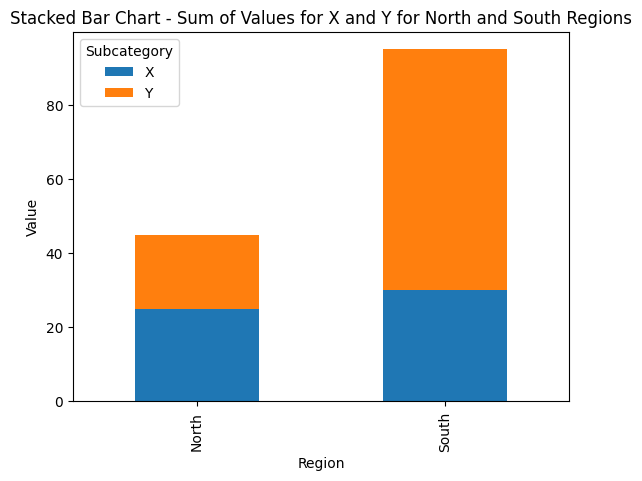

In [ ]:
# Pivot the DataFrame and sum up values for 'X' and 'Y' separately for 'North' and 'South'
pivot_table = df.pivot_table(index='Region', columns='Subcategory', values='Value', aggfunc='sum')
pivot_table
# Plotting
pivot_table.plot(kind='bar', stacked=True)
plt.xlabel('Region')
plt.ylabel('Value')
plt.title('Stacked Bar Chart - Sum of Values for X and Y for North and South Regions')
plt.legend(title='Subcategory')
plt.show()

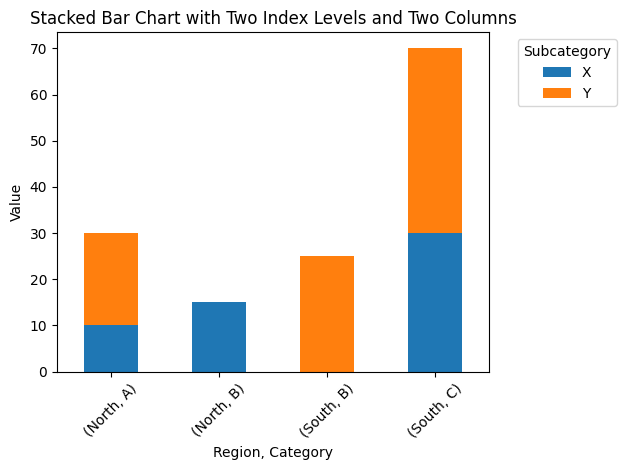

In [ ]:
# Create a sample DataFrame
data = {
    'Region': ['North', 'North', 'North', 'South', 'South', 'South'],
    'Category': ['A', 'A', 'B', 'B', 'C', 'C'],
    'Subcategory': ['X', 'Y', 'X', 'Y', 'X', 'Y'],
    'Value': [10, 20, 15, 25, 30, 40]
}

df = pd.DataFrame(data)

# Create a pivot table with two index levels and two columns
pivot_table = df.pivot_table(index=['Region', 'Category'], columns='Subcategory', values='Value', aggfunc='sum')
pivot_table
# Plotting
pivot_table.plot(kind='bar', stacked=True)
plt.xlabel('Region, Category')
plt.ylabel('Value')
plt.title('Stacked Bar Chart with Two Index Levels and Two Columns')
plt.legend(title='Subcategory', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-33-1b0c68ba43f7>:27: UserWarning:

FixedFormatter should only be used together with FixedLocator



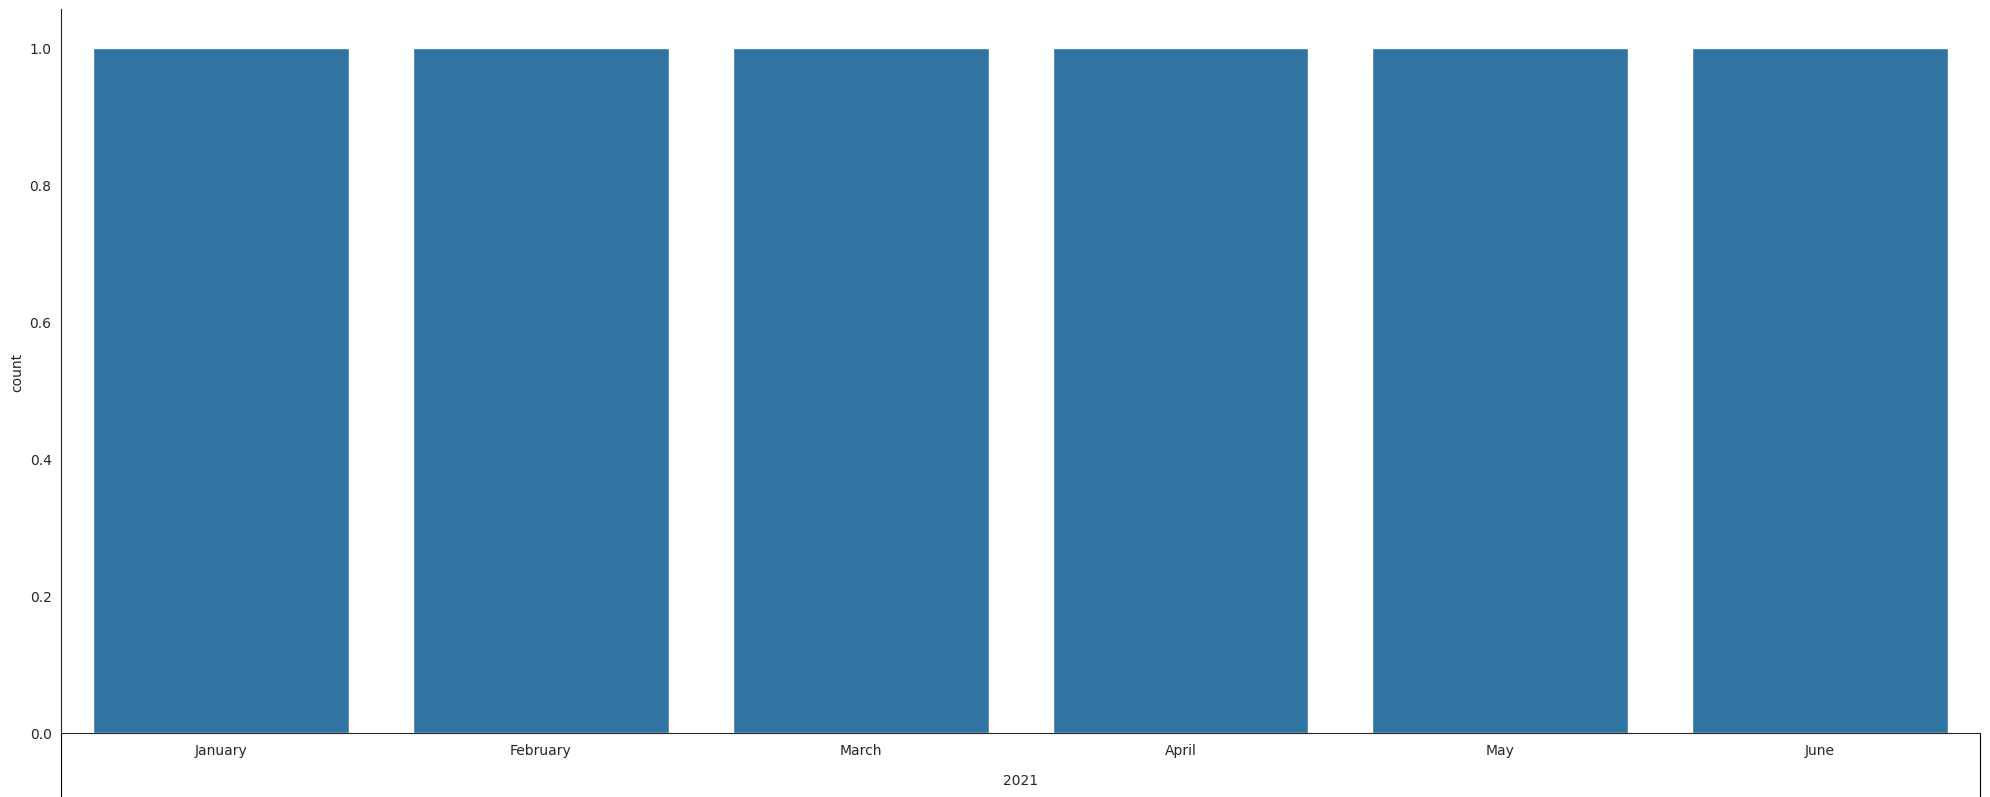

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample DataFrame
data = {
    'Region': ['North', 'North', 'North', 'South', 'South', 'South'],
    'Category': ['A', 'A', 'B', 'B', 'A', 'A'],
    'Upload Date': pd.date_range('2021-01-01', periods=6, freq='M'),
}

df = pd.DataFrame(data)

months = pd.date_range('2021-01-01', periods=12, freq='M').strftime('%B')
sns.set_style("white")
sns.set_color_codes("pastel")
fig, ax = plt.subplots(figsize=(20, 8))

# Assuming 'YearMonth' is a combination of 'Year' and 'Month' or 'Category' and 'Region'
df['YearMonth'] = df['Upload Date'].dt.strftime('%Y%m').astype(int)

sns.countplot(x='YearMonth', data=df, ax=ax)
sns.despine()

yearmonth_labels = sorted(df['YearMonth'].unique())
ax.set_xticklabels([months[ym % 100 - 1] for ym in yearmonth_labels])
ax.set_xlabel('')

# calculate the positions of the borders between the categories
pos = []
categories = []
prev = None
for i, ym in enumerate(yearmonth_labels):
    if ym // 100 != prev:
        pos.append(i)
        prev = ym // 100
        categories.append(prev)
pos.append(len(yearmonth_labels))
pos = np.array(pos) - 0.5

# vertical lines to separate the categories
ax.vlines(pos, 0, -0.12, color='black', lw=0.8, clip_on=False, transform=ax.get_xaxis_transform())

# categories at the center of their range
for category, pos0, pos1 in zip(categories, pos[:-1], pos[1:]):
    ax.text((pos0 + pos1) / 2, -0.07, category, ha='center', clip_on=False, transform=ax.get_xaxis_transform())

ax.set_xlim(pos[0], pos[-1])
ax.set_ylim(ymin=0)
plt.tight_layout()
plt.show()



In [ ]:
# Make sample df that resembles my data
cars_data =   {
    'City': ['A', 'A', 'A', 'B', 'B', 'B','B', 'B', 'B', 'C', 'C', 'C', 'C', 'C', 'C'],
    'Zip Code': ['91', '91','91', '92', '92', '92', '93', '93', '93', '94', '94', '94', '95', '95', '95'],
    'Fuel': ['G', 'H', 'PH', 'G', 'H', 'PH', 'G', 'H', 'PH', 'G', 'H', 'PH', 'G', 'H', 'PH'],
    'Group': ['Trad', 'Alt', 'Alt', 'Trad', 'Alt', 'Alt', 'Trad', 'Alt', 'Alt', 'Trad', 'Alt', 'Alt', 'Trad', 'Alt', 'Alt'],
    'Vehicles': [10, 3, 2, 50, 5, 6, 30, 6, 3, 40, 10, 8, 25, 3, 5]
}

sample_cars = pd.DataFrame(cars_data)
sample_cars

,City,Zip Code,Fuel,Group,Vehicles
0,A,91,G,Trad,10
1,A,91,H,Alt,3
2,A,91,PH,Alt,2
3,B,92,G,Trad,50
4,B,92,H,Alt,5
5,B,92,PH,Alt,6
6,B,93,G,Trad,30
7,B,93,H,Alt,6
8,B,93,PH,Alt,3
9,C,94,G,Trad,40


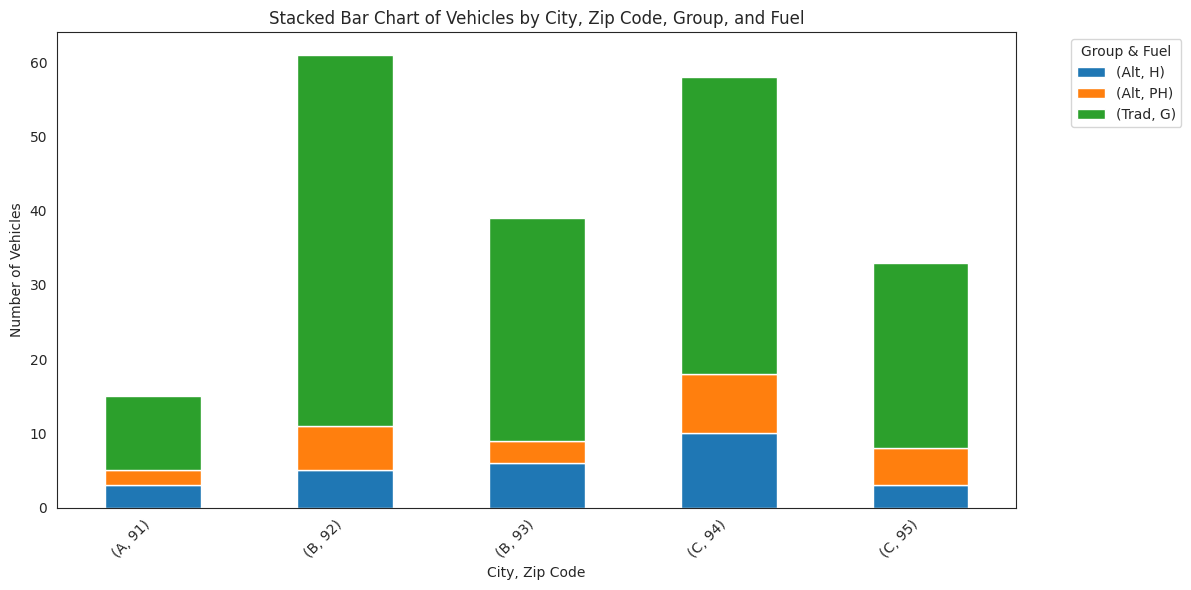

In [ ]:
# ChatGPT stacked bar chart suggestion

# Group by "City", "Zip Code", "Group", and "Fuel", summing the "Vehicles" column
grouped_df = sample_cars.groupby(['City', 'Zip Code', 'Group', 'Fuel'])['Vehicles'].sum().reset_index()

# Pivot the DataFrame to create a multi-level index
pivot_table = grouped_df.pivot_table(index=['City', 'Zip Code'], columns=['Group', 'Fuel'], values='Vehicles', fill_value=0)

# Plotting the stacked bar chart
pivot_table.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('City, Zip Code')
plt.ylabel('Number of Vehicles')
plt.title('Stacked Bar Chart of Vehicles by City, Zip Code, Group, and Fuel')
plt.legend(title='Group & Fuel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

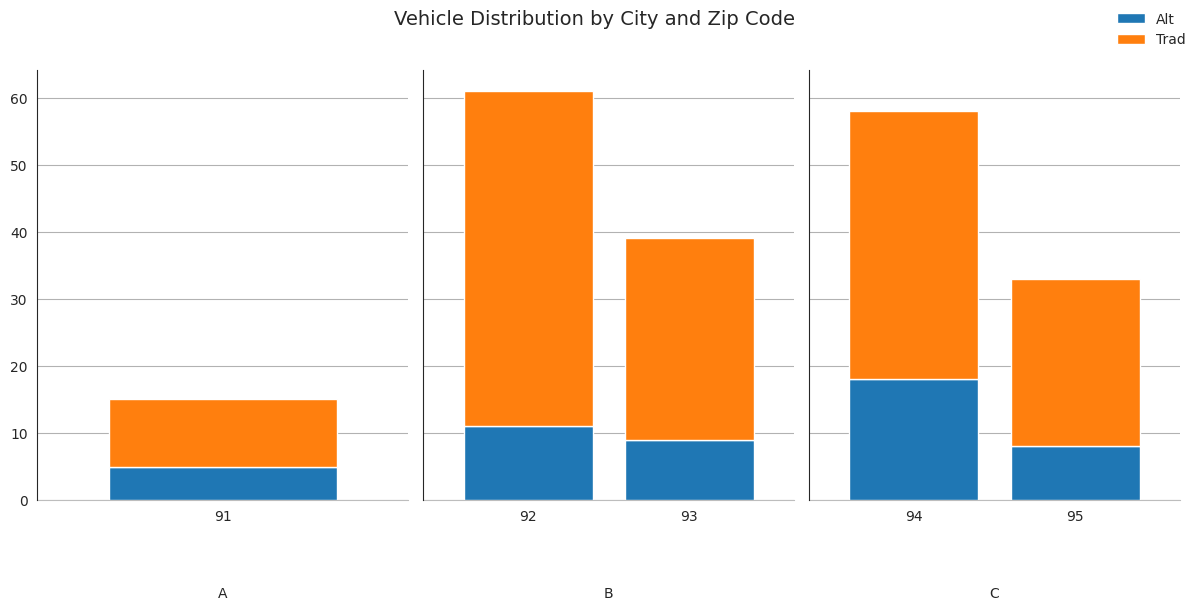

In [ ]:
# Stacked bar chart with multi-level x-axis
# https://stackoverflow.com/questions/51818724/plot-two-levels-of-x-ticklabels-on-a-pandas-multi-index-dataframe

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample DataFrame
cars_data = {
    'City': ['A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'C', 'C', 'C', 'C', 'C', 'C'],
    'Zip Code': ['91', '91', '91', '92', '92', '92', '93', '93', '93', '94', '94', '94', '95', '95', '95'],
    'Fuel': ['G', 'H', 'PH', 'G', 'H', 'PH', 'G', 'H', 'PH', 'G', 'H', 'PH', 'G', 'H', 'PH'],
    'Group': ['Trad', 'Alt', 'Alt', 'Trad', 'Alt', 'Alt', 'Trad', 'Alt', 'Alt', 'Trad', 'Alt', 'Alt', 'Trad', 'Alt', 'Alt'],
    'Vehicles': [10, 3, 2, 50, 5, 6, 30, 6, 3, 40, 10, 8, 25, 3, 5]
}

sample_cars = pd.DataFrame(cars_data)

# Pivot the DataFrame to create a multi-level index
pivot_table = sample_cars.pivot_table(index=['City', 'Zip Code'], columns='Group', values='Vehicles', aggfunc='sum', fill_value=0)

# Create figure with a subplot for each city
zones = pivot_table.index.levels[0]
nplots = len(zones)
fig, axes = plt.subplots(nrows=1, ncols=nplots, sharey=True, figsize=(12, 6))

# Loop through array of axes to create stacked bar chart for each city
alpha = 0.3  # used for grid lines, bottom spine, and separation lines between zones
for zone, ax in zip(zones, axes):
    # Create stacked bar chart with grid lines and no spines except bottom one
    pivot_table.loc[zone].plot.bar(ax=ax, legend=None, zorder=2, stacked=True, width=0.8)
    ax.grid(axis='y', zorder=1, color='black', alpha=alpha)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_alpha(alpha)

    # Set and place x labels for zip codes
    ax.set_xlabel(zone)
    ax.xaxis.set_label_coords(x=0.5, y=-0.2)

    # Format major tick labels for zip codes
    ax.set_xticklabels(pivot_table.loc[zone].index, rotation=0, ha='center')
    ax.tick_params(axis='both', length=0, pad=7)

    # Set and format minor tick marks for separation lines between cities
    ax.set_xticks(np.arange(len(pivot_table.loc[zone])) + 0.5, minor=True)
    ax.tick_params(which='minor', length=55, width=0.8, color=[0, 0, 0, alpha])

# Add legend using the labels and handles from the last subplot
fig.legend(*ax.get_legend_handles_labels(), frameon=False, loc='upper right')

fig.suptitle('Vehicle Distribution by City and Zip Code', y=1.02, size=14)
plt.tight_layout()
plt.show()



In [ ]:
# Add "Group" to cars_SMC

# First make tidy df before we pivot of just Zip, Fuel and Vehicle count
zip1 = cars_SMC.groupby(['Zip Code', 'City', 'Fuel']).sum('Vehicles').reset_index()
zip1

# Make a directory where the keys are the Fuel types and the values are Traditional, Alternative or Other
# fuel_group_1 = {'Gasoline':'Traditional'
#                    ,'Hybrid Gasoline':'Alternative'
#                    ,'Battery Electric':'Alternative'
#                    ,'Flex-Fuel':'Alternative'
#                    ,'Diesel and Diesel Hybrid':'Traditional'
#                    ,'Unk':'Other'
#                    ,'Plug-in Hybrid':'Alternative'
#                    ,'Hydrogen Fuel Cell':'Alternative'
#                    ,'Natural Gas':'Alternative'
#                    ,'Other':'Other'}

# cars_SMC_group = pd.merge(zip1, fuel_SMC_1_data, on='Fuel', how='inner')
# cars_SMC_group

#

,Zip Code,City,Fuel,Vehicles
0,94002,Belmont,Battery Electric,1568
1,94002,Belmont,Diesel and Diesel Hybrid,374
2,94002,Belmont,Flex-Fuel,479
3,94002,Belmont,Gasoline,16715
4,94002,Belmont,Hybrid Gasoline,1721
...,...,...,...,...
401,94404,San Mateo,Unk,276
402,94405,San Mateo,Gasoline,2
403,94405,San Mateo,Hybrid Gasoline,1
404,94407,San Mateo,Gasoline,5


In [ ]:
# Apply the ChatGPT code to the regular dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pivot the DataFrame to create a multi-level index
pivot_table = cars_SMC.pivot_table(index=['City', 'Zip Code'], columns='Group', values='Vehicles', aggfunc='sum', fill_value=0)

# Create figure with a subplot for each city
zones = pivot_table.index.levels[0]
nplots = len(zones)
fig, axes = plt.subplots(nrows=1, ncols=nplots, sharey=True, figsize=(12, 6))

# Loop through array of axes to create stacked bar chart for each city
alpha = 0.3  # used for grid lines, bottom spine, and separation lines between zones
for zone, ax in zip(zones, axes):
    # Create stacked bar chart with grid lines and no spines except bottom one
    pivot_table.loc[zone].plot.bar(ax=ax, legend=None, zorder=2, stacked=True, width=0.8)
    ax.grid(axis='y', zorder=1, color='black', alpha=alpha)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_alpha(alpha)

    # Set and place x labels for zip codes
    ax.set_xlabel(zone)
    ax.xaxis.set_label_coords(x=0.5, y=-0.2)

    # Format major tick labels for zip codes
    ax.set_xticklabels(pivot_table.loc[zone].index, rotation=0, ha='center')
    ax.tick_params(axis='both', length=0, pad=7)

    # Set and format minor tick marks for separation lines between cities
    ax.set_xticks(np.arange(len(pivot_table.loc[zone])) + 0.5, minor=True)
    ax.tick_params(which='minor', length=55, width=0.8, color=[0, 0, 0, alpha])

# Add legend using the labels and handles from the last subplot
fig.legend(*ax.get_legend_handles_labels(), frameon=False, loc='upper right')

fig.suptitle('Vehicle Distribution by City and Zip Code', y=1.02, size=14)
plt.tight_layout()
plt.show()


KeyError: 'Group'

In [ ]:
car_makes = pd.DataFrame(cars_SMC.groupby('Make')['Vehicles'].sum().reset_index())
car_makes

True

<Axes: xlabel='Make'>

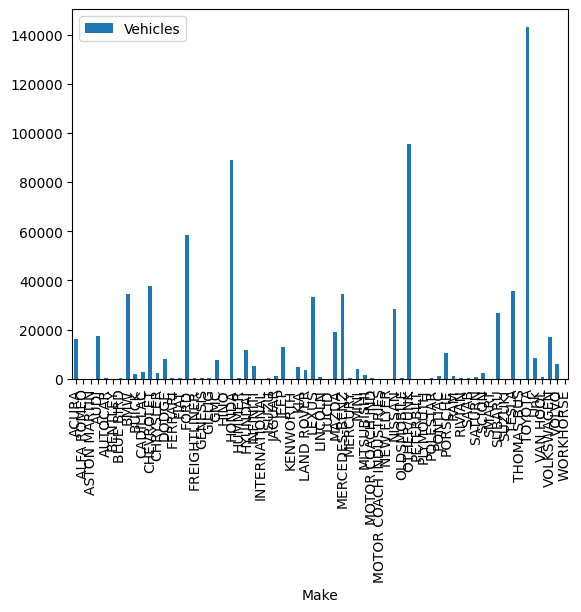

In [ ]:
car_makes.plot(kind='bar', x='Make')

## 01.4 - Filtering to just trad vs alt for Eden

In [ ]:
# First, narrow down the cars_SMC df to just the City, Zip Code, Fuel and count of Vehicles

# Make new df with just relevant columns
# Select columns to keep
columns_to_keep = ['Zip Code', 'Fuel', 'Vehicles', 'City']
fuel_zip_0 = cars_SMC[columns_to_keep]

# Groupby and sum vehicles
fuel_zip = fuel_zip_0.groupby(['City', 'Zip Code', 'Fuel'])['Vehicles'].sum().reset_index()
fuel_zip

,City,Zip Code,Fuel,Vehicles
0,Airport Mail Center,94128,Battery Electric,2
1,Airport Mail Center,94128,Diesel and Diesel Hybrid,38
2,Airport Mail Center,94128,Flex-Fuel,154
3,Airport Mail Center,94128,Gasoline,417
4,Airport Mail Center,94128,Hybrid Gasoline,15
...,...,...,...,...
401,Woodside,94062,Hydrogen Fuel Cell,8
402,Woodside,94062,Natural Gas,8
403,Woodside,94062,Other,1
404,Woodside,94062,Plug-in Hybrid,565


In [ ]:
# Second, assign each fuel type a group (alternative, traditional, other)

# Make a directory where the keys are the Fuel types and the values are Traditional, Alternative or Other
fuel_group_1 = {'Gasoline':'Traditional'
                   ,'Hybrid Gasoline':'Alternative'
                   ,'Battery Electric':'Alternative'
                   ,'Flex-Fuel':'Alternative'
                   ,'Diesel and Diesel Hybrid':'Traditional'
                   ,'Unk':'Other'
                   ,'Plug-in Hybrid':'Alternative'
                   ,'Hydrogen Fuel Cell':'Alternative'
                   ,'Natural Gas':'Alternative'
                   ,'Other':'Other'}

# Map variable and assign output to new variable. Add up by Group and assign to new dataframe
fuel_zip_1 = fuel_zip.assign(Group = fuel_zip.Fuel.map(fuel_group_1))


,City,Zip Code,Fuel,Vehicles,Group
0,Airport Mail Center,94128,Battery Electric,2,Alternative
1,Airport Mail Center,94128,Diesel and Diesel Hybrid,38,Traditional
2,Airport Mail Center,94128,Flex-Fuel,154,Alternative
3,Airport Mail Center,94128,Gasoline,417,Traditional
4,Airport Mail Center,94128,Hybrid Gasoline,15,Alternative
...,...,...,...,...,...
401,Woodside,94062,Hydrogen Fuel Cell,8,Alternative
402,Woodside,94062,Natural Gas,8,Alternative
403,Woodside,94062,Other,1,Other
404,Woodside,94062,Plug-in Hybrid,565,Alternative


In [ ]:
# Third, sum by Group to get the number of each type by zip
fuel_cat_zip = fuel_zip_1.groupby('City', 'Zip Code', 'Group')['Vehicles'].sum().reset_index()
fuel_cat_zip

ValueError: No axis named Zip Code for object type DataFrame

In [ ]:
# Group together fuel types into different categories
# Traditional VS Alternative Fuel

# Make a directory where the keys are the Fuel types and the values are Traditional, Alternative or Other
fuel_group_1 = {'Gasoline':'Traditional'
                   ,'Hybrid Gasoline':'Alternative'
                   ,'Battery Electric':'Alternative'
                   ,'Flex-Fuel':'Alternative'
                   ,'Diesel and Diesel Hybrid':'Traditional'
                   ,'Unk':'Other'
                   ,'Plug-in Hybrid':'Alternative'
                   ,'Hydrogen Fuel Cell':'Alternative'
                   ,'Natural Gas':'Alternative'
                   ,'Other':'Other'}
# Map variable and assign output to new variable. Add up by Group and assign to new dataframe
fuel_SMC_1_data = cars_SMC.assign(Group = cars_SMC.Fuel.map(fuel_group_1))
fuel_SMC_1_data
# Do this next part if you want a tidyier dataframe of just trad/alt/other. Keep as is for stacked bar plot
fuel_SMC_1_data = fuel_SMC_1_data.groupby('Group').count()

fuel_SMC_1 = pd.DataFrame(data=fuel_SMC_1_data).reset_index()
fuel_SMC_1.columns = ["Group", "Count"]
fuel_SMC_1

In [ ]:
cars_SMC

,Date,Zip Code,Model Year,Fuel,Make,Duty,Vehicles,City
0,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Heavy,2,Belmont
1,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Light,65,Belmont
2,12/31/2022,94002,2008,Gasoline,OTHER/UNK,Unk,25,Belmont
3,12/31/2022,94002,2008,Gasoline,FORD,Light,33,Belmont
4,12/31/2022,94002,2008,Gasoline,CHEVROLET,Light,11,Belmont
...,...,...,...,...,...,...,...,...
19451,12/31/2022,94405,2015,Gasoline,OTHER/UNK,Light,2,San Mateo
19452,12/31/2022,94407,2011,Gasoline,OTHER/UNK,Light,1,San Mateo
19453,12/31/2022,94407,2014,Gasoline,OTHER/UNK,Light,1,San Mateo
19454,12/31/2022,94407,<2009,Gasoline,OTHER/UNK,Light,3,San Mateo


# 00 - Filtering to SMC

In [ ]:
# Upload cars data from local drive
cars_CA = pd.read_csv("vehicle-fuel-type-count-by-zip-code-2022.csv", low_memory=False)

FileNotFoundError: [Errno 2] No such file or directory: 'vehicle-fuel-type-count-by-zip-code-2022.csv'

In [ ]:
cars_CA

,Date,Zip Code,Model Year,Fuel,Make,Duty,Vehicles
0,12/31/2022,90000,2010,Gasoline,OTHER/UNK,Light,1
1,12/31/2022,90000,2012,Hybrid Gasoline,OTHER/UNK,Light,1
2,12/31/2022,90000,2013,Gasoline,OTHER/UNK,Light,1
3,12/31/2022,90000,<2009,Gasoline,OTHER/UNK,Heavy,19
4,12/31/2022,90000,<2009,Gasoline,OTHER/UNK,Light,16
...,...,...,...,...,...,...,...
765265,12/31/2022,99934,2016,Gasoline,OTHER/UNK,Light,1
765266,12/31/2022,99959,<2009,Gasoline,OTHER/UNK,Light,1
765267,12/31/2022,99990,2012,Diesel and Diesel Hybrid,OTHER/UNK,Heavy,1
765268,12/31/2022,99999,2008,Gasoline,OTHER/UNK,Light,1


In [ ]:
# Upload list of San Mateo County zip codes
list_SMC = pd.read_csv("SMC_Zipcodes.csv")
list_SMC

,Zip Code,City
0,94002,Belmont
1,94003,Belmont
2,94005,Brisbane
3,94010,Burlingame
4,94010,Hillsborough
...,...,...
58,94405,San Mateo
59,94406,San Mateo
60,94407,San Mateo
61,94408,San Mateo


In [ ]:
# We need to filter the statewide dataset to just SMC zip codes

# 'Zip Code' column needs to be integers so we need to remove 'OOS' codes
# Change all non-numeric values to NaN and filter
cars_CA['Zip Code'] = cars_CA['Zip Code'].str.extract('(\d+)', expand = False)
cars_CA.dropna(subset=["Zip Code"], inplace=True)

# Change 'Zip Code' column in cars_CA from object to int64
cars_CA['Zip Code']=cars_CA['Zip Code'].astype(int)

cars_CA

,Date,Zip Code,Model Year,Fuel,Make,Duty,Vehicles
0,12/31/2022,90000,2010,Gasoline,OTHER/UNK,Light,1
1,12/31/2022,90000,2012,Hybrid Gasoline,OTHER/UNK,Light,1
2,12/31/2022,90000,2013,Gasoline,OTHER/UNK,Light,1
3,12/31/2022,90000,<2009,Gasoline,OTHER/UNK,Heavy,19
4,12/31/2022,90000,<2009,Gasoline,OTHER/UNK,Light,16
...,...,...,...,...,...,...,...
765265,12/31/2022,99934,2016,Gasoline,OTHER/UNK,Light,1
765266,12/31/2022,99959,<2009,Gasoline,OTHER/UNK,Light,1
765267,12/31/2022,99990,2012,Diesel and Diesel Hybrid,OTHER/UNK,Heavy,1
765268,12/31/2022,99999,2008,Gasoline,OTHER/UNK,Light,1


In [ ]:
# Filter cars_CA to only include SMC zip codes
cars_SMC = pd.merge(cars_CA, list_SMC, on='Zip Code', how='inner')
cars_SMC

NameError: name 'cars_CA' is not defined

In [ ]:
# Download CSV to upload to GitHub
from google.colab import files
cars_SMC.to_csv('cars_SMC.csv')
files.download('cars_SMC.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>